## **1. Problem Description**

This project performs a Responsible AI audit of the **NYPD 2024 Stop, Question and Frisk (SQF)** dataset, published by the New York City Police Department.

The goals are to:

- Train a model to predict **whether a stop results in an arrest**.
- Measure **model quality and fairness** across demographic groups.
- Detect and correct **proxy features** and **pre-existing bias** in the data.
- Apply **bias mitigation** by reweighing and Additive Counterfactual Fairness.
- Explain how the model makes decisions, globally and locally, **before and after** mitigation.

## **2. Data Understanding**

### **Dataset name:** NYPD Stop, Question and Frisk (SQF) – 2024  

### **Imports**


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy import sparse
from collections import defaultdict
import shap
pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)

### **Loading Data**

In [2]:
odf = pd.read_excel('/content/drive/MyDrive/RAI project/dataset.xlsx')

### **Metadata Understanding**

In [3]:
odf.columns

Index(['STOP_ID', 'STOP_FRISK_DATE', 'STOP_FRISK_TIME', 'YEAR2', 'MONTH2',
       'DAY2', 'STOP_WAS_INITIATED', 'ISSUING_OFFICER_RANK',
       'ISSUING_OFFICER_COMMAND_CODE', 'SUPERVISING_OFFICER_RANK',
       'SUPERVISING_OFFICER_COMMAND_CODE',
       'SUPERVISING_ACTION_CORRESPONDING_ACTIVITY_LOG_ENTRY_REVIEWED',
       'LOCATION_IN_OUT_CODE', 'JURISDICTION_CODE', 'JURISDICTION_DESCRIPTION',
       'OBSERVED_DURATION_MINUTES', 'SUSPECTED_CRIME_DESCRIPTION',
       'STOP_DURATION_MINUTES', 'OFFICER_EXPLAINED_STOP_FLAG',
       'OFFICER_NOT_EXPLAINED_STOP_DESCRIPTION', 'OTHER_PERSON_STOPPED_FLAG',
       'SUSPECT_ARRESTED_FLAG', 'SUSPECT_ARREST_OFFENSE',
       'SUMMONS_ISSUED_FLAG', 'SUMMONS_OFFENSE_DESCRIPTION',
       'OFFICER_IN_UNIFORM_FLAG', 'ID_CARD_IDENTIFIES_OFFICER_FLAG',
       'SHIELD_IDENTIFIES_OFFICER_FLAG', 'VERBAL_IDENTIFIES_OFFICER_FLAG',
       'FRISKED_FLAG', 'SEARCHED_FLAG', 'ASK_FOR_CONSENT_FLG',
       'CONSENT_GIVEN_FLG', 'OTHER_CONTRABAND_FLAG', 'FIREARM_FLAG',


In [4]:
odf.shape

(25386, 81)

In [5]:
odf.head()

,STOP_ID,STOP_FRISK_DATE,STOP_FRISK_TIME,YEAR2,MONTH2,DAY2,STOP_WAS_INITIATED,ISSUING_OFFICER_RANK,ISSUING_OFFICER_COMMAND_CODE,SUPERVISING_OFFICER_RANK,SUPERVISING_OFFICER_COMMAND_CODE,SUPERVISING_ACTION_CORRESPONDING_ACTIVITY_LOG_ENTRY_REVIEWED,LOCATION_IN_OUT_CODE,JURISDICTION_CODE,JURISDICTION_DESCRIPTION,OBSERVED_DURATION_MINUTES,SUSPECTED_CRIME_DESCRIPTION,STOP_DURATION_MINUTES,OFFICER_EXPLAINED_STOP_FLAG,OFFICER_NOT_EXPLAINED_STOP_DESCRIPTION,OTHER_PERSON_STOPPED_FLAG,SUSPECT_ARRESTED_FLAG,SUSPECT_ARREST_OFFENSE,SUMMONS_ISSUED_FLAG,SUMMONS_OFFENSE_DESCRIPTION,OFFICER_IN_UNIFORM_FLAG,ID_CARD_IDENTIFIES_OFFICER_FLAG,SHIELD_IDENTIFIES_OFFICER_FLAG,VERBAL_IDENTIFIES_OFFICER_FLAG,FRISKED_FLAG,SEARCHED_FLAG,ASK_FOR_CONSENT_FLG,CONSENT_GIVEN_FLG,OTHER_CONTRABAND_FLAG,FIREARM_FLAG,KNIFE_CUTTER_FLAG,OTHER_WEAPON_FLAG,WEAPON_FOUND_FLAG,PHYSICAL_FORCE_CEW_FLAG,PHYSICAL_FORCE_DRAW_POINT_FIREARM_FLAG,PHYSICAL_FORCE_HANDCUFF_SUSPECT_FLAG,PHYSICAL_FORCE_OC_SPRAY_USED_FLAG,PHYSICAL_FORCE_OTHER_FLAG,PHYSICAL_FORCE_RESTRAINT_USED_FLAG,PHYSICAL_FORCE_VERBAL_INSTRUCTION_FLAG,PHYSICAL_FORCE_WEAPON_IMPACT_FLAG,BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG,BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG,SUSPECTS_ACTIONS_CASING_FLAG,SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG,SUSPECTS_ACTIONS_DECRIPTION_FLAG,SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG,SUSPECTS_ACTIONS_IDENTIFY_CRIME_PATTERN_FLAG,SUSPECTS_ACTIONS_LOOKOUT_FLAG,SUSPECTS_ACTIONS_OTHER_FLAG,SUSPECTS_ACTIONS_PROXIMITY_TO_SCENE_FLAG,SEARCH_BASIS_ADMISSION_FLAG,SEARCH_BASIS_CONSENT_FLAG,SEARCH_BASIS_HARD_OBJECT_FLAG,SEARCH_BASIS_INCIDENTAL_TO_ARREST_FLAG,SEARCH_BASIS_OTHER_FLAG,SEARCH_BASIS_OUTLINE_FLAG,DEMEANOR_OF_PERSON_STOPPED,SUSPECT_REPORTED_AGE,SUSPECT_SEX,SUSPECT_RACE_DESCRIPTION,SUSPECT_HEIGHT,SUSPECT_WEIGHT,SUSPECT_BODY_BUILD_TYPE,SUSPECT_EYE_COLOR,SUSPECT_HAIR_COLOR,SUSPECT_OTHER_DESCRIPTION,STOP_LOCATION_PRECINCT,STOP_LOCATION_SECTOR_CODE,STOP_LOCATION_APARTMENT,STOP_LOCATION_FULL_ADDRESS,STOP_LOCATION_STREET_NAME,STOP_LOCATION_X,STOP_LOCATION_Y,STOP_LOCATION_PATROL_BORO_NAME,STOP_LOCATION_BORO_NAME
0,279772561,2024-01-01,01:58:00,2024,January,Monday,Based on Self Initiated,PO,46,SGT,46,Y,O,P,PSB,1,CPW,1,N,ARREST,N,Y,CPW,N,(null),Y,(null),(null),(null),Y,Y,N,N,N,Y,(null),(null),Y,(null),Y,(null),(null),(null),(null),Y,(null),(null),(null),(null),Y,(null),(null),(null),(null),(null),(null),(null),(null),Y,Y,(null),(null),NERVOUS,27,MALE,WHITE HISPANIC,5.11,160,THN,BRO,BLK,(null),046,A,(null),1775 CLAY AVE,CLAY AVE,1010576,247603,PBBX,BRONX
1,279772564,2024-01-01,00:48:00,2024,January,Monday,Based on Self Initiated,PO,120,SGT,67,Y,O,(null),(null),1,CPW,3,Y,(null),N,N,(null),N,(null),Y,(null),(null),(null),Y,Y,N,N,N,Y,(null),(null),Y,(null),(null),(null),(null),(null),(null),Y,(null),(null),(null),(null),Y,(null),(null),(null),(null),(null),(null),(null),(null),Y,(null),(null),(null),NaN,22,MALE,BLACK,6.1,200,MED,BRO,BLK,BLACK HOODIE SWEATSHIRT,067,D,(null),4515 FARRAGUT RD,FARRAGUT RD,1002798,171482,PBBS,BROOKLYN
2,279772565,2024-01-01,01:10:00,2024,January,Monday,Based on Radio Run,PO,871,SGT,871,Y,S,T,Transit,0,GRAND LARCENY,20,Y,(null),Y,N,(null),N,(null),Y,(null),(null),(null),Y,N,N,N,N,(null),(null),(null),N,(null),(null),(null),(null),(null),(null),Y,(null),(null),(null),(null),(null),Y,(null),(null),(null),(null),Y,(null),(null),(null),(null),(null),(null),NORMAL,17,MALE,WHITE HISPANIC,6.0,140,THN,BRO,BLK,SCAR ON LIP,068,D,(null),&&,NaN,977764,170616,PBBS,BROOKLYN
3,279772566,2024-01-01,01:10:00,2024,January,Monday,Based on Radio Run,PO,871,SGT,871,Y,S,T,Transit,0,GRAND LARCENY,20,Y,(null),Y,N,(null),N,(null),Y,(null),(null),(null),Y,N,N,N,N,(null),(null),(null),N,(null),(null),(null),(null),(null),(null),Y,(null),(null),(null),(null),(null),Y,(null),(null),(null),(null),Y,(null),(null),(null),(null),(null),(null),NORMAL,13,MALE,WHITE HISPANIC,5.0,120,THN,BRO,BLK,RED JACKET/ RED HAT,068,D,(null),&&,NaN,977764,170616,PBBS,BROOKLYN
4,279772567,2024-01-01,01:10:

In [6]:
odf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25386 entries, 0 to 25385
Data columns (total 81 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   STOP_ID                                                       25386 non-null  int64 
 1   STOP_FRISK_DATE                                               25386 non-null  object
 2   STOP_FRISK_TIME                                               25386 non-null  object
 3   YEAR2                                                         25386 non-null  int64 
 4   MONTH2                                                        25386 non-null  object
 5   DAY2                                                          25386 non-null  object
 6   STOP_WAS_INITIATED                                            25386 non-null  object
 7   ISSUING_OFFICER_RANK                                          25386 non-null

### **Summary**

- Number of rows: `25386`
- Number of features: `81`
- Target considered: `SUSPECT_ARRESTED_FLAG` (Y/N).
- Protected features:
  - Race: `SUSPECT_RACE_DESCRIPTION`
  - Sex: `SUSPECT_SEX`
  - Age: `SUSPECT_REPORTED_AGE`
  - Height: `SUSPECT_HEIGHT`
  - Weight: `SUSPECT_WEIGHT`
  - Build Type: `SUSPECT_BODY_BUILD_TYPE`
- Other relevant groups:
  - Boroughs: `STOP_LOCATION_BORO_NAME`
  - Jurisdiction: `JURISDICTION_CODE` and `JURISDICTION_DESCRIPTION`

## **3. Problem Understanding**

### **Hypotheses about Protected and Proxy Features**


#### **Protected Features**

We consider the following feartures as **sensitive/protected**:

- **Race** (`SUSPECT_RACE_DESCRIPTION`):  
  Stop-and-frisk has historically shown large racial disparities, with Black and Latino people making up the vast majority of those stopped. Using race directly in a decision-making model about arrests raises serious fairness and constitutional concerns.
- **Sex** (`SUSPECT_SEX`):  
  Different treatment by sex may reinforce gender inequities in policing practices.
- **Age** (`SUSPECT_REPORTED_AGE`):  
  Younger people, particularly youth of color, may be disproportionately stopped and arrested. Age is also often subject to special legal protections.

These variables will primarily be used for **fairness analysis**

#### **Proxy Features**

The following features may act as **proxies for protected attributes**:

- **`STOP_LOCATION_PRECINCT` / `STOP_LOCATION_BORO_NAME` / `JURISDICTION_CODE`**:  
  NYPD precinct and borough boundaries strongly correlate with neighborhood racial composition and socio-economic status. Decisions based on location can therefore indirectly reproduce racial disparities even if race is not explicitly used.
- **`SUSPECT_HEIGHT` / `SUSPECT_WEIGHT`/ `SUSPECT_BODY_BUILD_TYPE`**
  These may reflect the age or gender of the individual and might act as a proxy for the age and gender features.
- **`SUSPECTED_CRIME_DESCRIPTION`**:  
  Certain offense categories may be more heavily enforced in particular neighborhoods or against particular groups, potentially encoding structural and enforcement bias.



## **4. Data Pre-processing**

#### **Columns to Drop**

In [7]:
cols_to_drop = [
    'STOP_ID', 'STOP_FRISK_DATE', 'YEAR2', 'ISSUING_OFFICER_RANK', 'ISSUING_OFFICER_COMMAND_CODE', 'SUPERVISING_OFFICER_RANK', 'SUPERVISING_OFFICER_COMMAND_CODE',
    'SUPERVISING_ACTION_CORRESPONDING_ACTIVITY_LOG_ENTRY_REVIEWED', 'LOCATION_IN_OUT_CODE', 'JURISDICTION_DESCRIPTION', 'OFFICER_EXPLAINED_STOP_FLAG',
    'OFFICER_NOT_EXPLAINED_STOP_DESCRIPTION', 'OTHER_PERSON_STOPPED_FLAG', 'SUMMONS_ISSUED_FLAG',
    'SUMMONS_OFFENSE_DESCRIPTION', 'OFFICER_IN_UNIFORM_FLAG', 'ID_CARD_IDENTIFIES_OFFICER_FLAG', 'SHIELD_IDENTIFIES_OFFICER_FLAG', 'VERBAL_IDENTIFIES_OFFICER_FLAG',
    'ASK_FOR_CONSENT_FLG', 'CONSENT_GIVEN_FLG', 'OTHER_CONTRABAND_FLAG', 'FIREARM_FLAG', 'KNIFE_CUTTER_FLAG', 'FIREARM_FLAG', 'OTHER_WEAPON_FLAG',
    'SUSPECTS_ACTIONS_DECRIPTION_FLAG',
    'SEARCH_BASIS_ADMISSION_FLAG', 'SEARCH_BASIS_CONSENT_FLAG', 'SEARCH_BASIS_HARD_OBJECT_FLAG', 'SEARCH_BASIS_INCIDENTAL_TO_ARREST_FLAG', 'SEARCH_BASIS_OTHER_FLAG',
    'SEARCH_BASIS_OUTLINE_FLAG', 'SUSPECT_EYE_COLOR', 'SUSPECT_HAIR_COLOR', 'STOP_LOCATION_PRECINCT',  'STOP_LOCATION_SECTOR_CODE', 'STOP_LOCATION_APARTMENT', 'STOP_LOCATION_FULL_ADDRESS', 'STOP_LOCATION_X',
    'STOP_LOCATION_Y', 'STOP_LOCATION_PATROL_BORO_NAME',
    'SUSPECT_ARREST_OFFENSE', 'STOP_LOCATION_STREET_NAME'
]

df = odf.drop(columns=cols_to_drop, errors='ignore')

#### **Null Values**

In [8]:
df = df.replace({"(null)": np.nan, "": np.nan})

#### **Standardizing Columns**

In [9]:
# Suspected Crime Description Column
crime_map = {
    'ROBBERY': 'violent',
    'ASSAULT': 'violent',
    'MENACING': 'violent',
    'RECKLESS ENDANGERMENT': 'violent',
    'MURDER': 'violent',
    'RAPE': 'violent',
    'FORCIBLE TOUCHING': 'violent',
    'TERRORISM': 'violent',
    'BURGLARY': 'property',
    'PETIT LARCENY': 'property',
    'GRAND LARCENY': 'property',
    'GRAND LARCENY AUTO': 'property',
    'AUTO STRIPPING': 'property',
    'AUTO STRIPPIG': 'property',
    'MAKING GRAFFITI': 'property',
    'CRIMINAL MISCHIEF': 'property',
    'UNAUTHORIZED USE OF A VEHICLE': 'property',
    'THEFT OF SERVICES': 'property',
    'CPW': 'weapon',
    'CPSP': 'weapon',
    'CRIMINAL POSSESSION OF CONTROLLED SUBSTANCE': 'drug',
    'CRIMINAL SALE OF CONTROLLED SUBSTANCE': 'drug',
    'CRIMINAL POSSESSION OF MARIHUANA': 'drug',
    'CRIMINAL SALE OF MARIHUANA': 'drug',
    'CRIMINAL TRESPASS': 'minor',
    'PROSTITUTION': 'minor',
    'CRIMINAL POSSESSION OF FORGED INSTRUMENT': 'minor',
    'OTHER': 'other'
}

df['crime_group'] = df['SUSPECTED_CRIME_DESCRIPTION'].map(crime_map)

# Build Type Column
df["build_type"] = (
    df["SUSPECT_BODY_BUILD_TYPE"]
    .replace({"U": np.nan, "XXX": np.nan})
    .map({"THN": "THIN", "MED": "MEDIUM", "HEA": "HEAVY"})
)

# Background Violen Crime
df["bg_violent_crime"] = (df["BACKROUND_CIRCUMSTANCES_VIOLENT_CRIME_FLAG"] == "Y").astype(int)

# Suspect Arrested Column
df["arrested"] = df["SUSPECT_ARRESTED_FLAG"].map({"Y":1, "N":0}).astype(int)

# Gender Column
df["sex"] = (df["SUSPECT_SEX"].str.upper().map({"MALE": 1, "FEMALE": 0}).astype("Int64"))


#### **Feature Engineering**

In [10]:
# Race
race_map = {
    'BLACK': 'Black',
    'WHITE HISPANIC': 'Hispanic',
    'BLACK HISPANIC': 'Hispanic',
    'WHITE': 'White',
    'ASIAN / PACIFIC ISLANDER': 'Other',
    'MIDDLE EASTERN/SOUTHWEST ASIAN': 'Other',
    'AMERICAN INDIAN/ALASKAN NATIVE': 'Other'
}
df['race_group'] = df['SUSPECT_RACE_DESCRIPTION'].map(race_map)

# Age
df['age_bin'] = pd.cut(
    df['SUSPECT_REPORTED_AGE'],
    bins=[0, 17, 24, 34, 44, 54, 64, 120],
    labels=[
        '0-17',
        '18-24',
        '25-34',
        '35-44',
        '45-54',
        '55-64',
        '65+'
    ],
    include_lowest=True
)


# Suspect Action Column
action_cols = [
    "SUSPECTS_ACTIONS_CASING_FLAG",
    "SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG",
    "SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG",
    "SUSPECTS_ACTIONS_IDENTIFY_CRIME_PATTERN_FLAG",
    "SUSPECTS_ACTIONS_LOOKOUT_FLAG",
    "SUSPECTS_ACTIONS_OTHER_FLAG",
    "SUSPECTS_ACTIONS_PROXIMITY_TO_SCENE_FLAG",
]
for c in action_cols:
    df[c] = (df[c] == "Y").astype(int)
df["actions_count"] = df[action_cols].sum(axis=1)


# Deneanor of person stopped Column
col = "DEMEANOR_OF_PERSON_STOPPED"
s = (
    df[col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"(NULL)": np.nan, "NONE": np.nan, "NAN": np.nan, "": np.nan})
)
POSITIVE = {"CALM","COOPERATIVE","COMPLIANT","RESPECTFUL","POLITE","RELAXED","CORDIAL","FRIENDLY"}
NEUTRAL  = {"NORMAL","QUIET","SILENT","NO REACTION","INDIFFERENT","NEUTRAL"}
NEGATIVE = {"NERVOUS","UPSET","ANNOYED","ANGRY","AGITATED","COMBATIVE","HOSTILE",
            "NON-COMPLIANT","BELLIGERENT","AGGRESSIVE","UNCOOPERATIVE","IRATE","DEFENSIVE","TENSE","CONFRONTATIONAL"}
KEYWORDS = {
    "POSITIVE": ["CALM","COOPERAT","COMPLIAN","RESPECT","POLITE","FRIEND","CORDIAL","RELAX"],
    "NEUTRAL":  ["NORMAL","QUIET","SILENT","NEUTRAL","NO REACTION","NONE"],
    "NEGATIVE": ["NERVOUS","UPSET","ANNOY","ANGRY","AGITAT","COMBAT","HOSTIL",
                 "NON-COMPL","BELLIG","AGGRESS","UNCOOPER","IRATE","DEFENS","TENSE","CONFRONT"]
}
def categorize(val: str) -> str:
    if pd.isna(val):
        return "UNKNOWN"
    v = val.strip().upper()
    if v in POSITIVE: return "Positive"
    if v in NEUTRAL:  return "Neutral"
    if v in NEGATIVE: return "Negative"
    for cat, kws in KEYWORDS.items():
        if any(kw in v for kw in kws):
            return cat
    return "OTHER"
df["DEMEANOR_STD"] = s
df["Demeanor Category"] = df["DEMEANOR_STD"].map(categorize)

# Frisk Time Column
def time_to_minutes(t):
    try:
        h, m, s = map(int, str(t).split(':'))
        return h*60 + m
    except:
        return None
df['STOP_FRISK_MINUTES'] = df['STOP_FRISK_TIME'].apply(time_to_minutes)

def time_bucket(mins):
    if pd.isna(mins): return np.nan
    if 0 <= mins < 360: return "LateNight"
    elif mins < 720: return "Morning"
    elif mins < 1080: return "Afternoon"
    else: return "Evening"
df['time_bucket'] = df['STOP_FRISK_MINUTES'].apply(time_bucket)

df['time_sin'] = np.sin(2 * np.pi * df['STOP_FRISK_MINUTES'] / 1440)
df['time_cos'] = np.cos(2 * np.pi * df['STOP_FRISK_MINUTES'] / 1440)

# Month Column
month_map = {m:i for i,m in enumerate(
    ["January","February","March","April","May","June","July","August",
     "September","October","November","December"], start=1)}
weekday_map = {"Monday":0,"Tuesday":1,"Wednesday":2,"Thursday":3,"Friday":4,"Saturday":5,"Sunday":6}

if "MONTH2" in df.columns: df["month"] = df["MONTH2"].map(month_map)
if "DAY2"   in df.columns: df["weekday"]   = df["DAY2"].map(weekday_map)

for cyc,mod in [("MONTH",12),("WEEKDAY",7)]:
    if cyc in df.columns:
        ang = 2*np.pi*df[cyc]/mod
        df[f"{cyc}_sin"] = np.sin(ang)
        df[f"{cyc}_cos"] = np.cos(ang)

#Force and Escalation Features
force_cols = [
    'PHYSICAL_FORCE_CEW_FLAG',
    'PHYSICAL_FORCE_DRAW_POINT_FIREARM_FLAG',
    'PHYSICAL_FORCE_HANDCUFF_SUSPECT_FLAG',
    'PHYSICAL_FORCE_OC_SPRAY_USED_FLAG',
    'PHYSICAL_FORCE_OTHER_FLAG',
    'PHYSICAL_FORCE_RESTRAINT_USED_FLAG',
    'PHYSICAL_FORCE_VERBAL_INSTRUCTION_FLAG',
    'PHYSICAL_FORCE_WEAPON_IMPACT_FLAG'
]
for c in force_cols:
    df[c] = (df[c] == "Y").astype(int)
df[force_cols] = df[force_cols].fillna(0)
# Force level
df['force_level'] = 0
#verbal instruction only
level1 = df['PHYSICAL_FORCE_VERBAL_INSTRUCTION_FLAG'] == 1
df.loc[level1, 'force_level'] = 1
#restraints / handcuffs
level2 = (
    (df[['PHYSICAL_FORCE_HANDCUFF_SUSPECT_FLAG',
         'PHYSICAL_FORCE_RESTRAINT_USED_FLAG']].sum(axis=1) > 0))
df.loc[level2, 'force_level'] = 2
#weapon-related force
level3 = (
    (df[['PHYSICAL_FORCE_OC_SPRAY_USED_FLAG',
         'PHYSICAL_FORCE_CEW_FLAG',
         'PHYSICAL_FORCE_WEAPON_IMPACT_FLAG',
         'PHYSICAL_FORCE_DRAW_POINT_FIREARM_FLAG']].sum(axis=1) > 0))
df.loc[level3, 'force_level'] = 3


#search features
search_cols = ['FRISKED_FLAG', 'SEARCHED_FLAG']
for c in search_cols:
    df[c] = (df[c] == "Y").astype(int)
df[search_cols] = df[search_cols].fillna(0)
df['search_any'] = (df[search_cols].sum(axis=1) > 0).astype(int)


#stop initiation feature
stop_initiation_map = {
    'Based on Self Initiated': 1,
    'Based on Radio Run': 2,
    'Based on C/W on Scene': 3
}

df['stop_initiation'] = df['STOP_WAS_INITIATED'].map(stop_initiation_map)



In [11]:
# Standardizing Column Names
rename_map = {
    "STOP_FRISK_TIME": "time",
    "MONTH2": "month_name",
    "DAY2": "day",
    "SUSPECT_ARREST_OFFENSE": "arrest_offense",
    "FRISKED_FLAG": "frisked",
    "SEARCHED_FLAG": "searched",
    "WEAPON_FOUND_FLAG": "weapon_found",
    "BACKROUND_CIRCUMSTANCES_SUSPECT_KNOWN_TO_CARRY_WEAPON_FLAG": "bg_carry_weapon",
    "SUSPECTS_ACTIONS_CASING_FLAG": "actions_casing",
    "SUSPECTS_ACTIONS_CONCEALED_POSSESSION_WEAPON_FLAG": "actions_concealed_weapon",
    "SUSPECTS_ACTIONS_DRUG_TRANSACTIONS_FLAG": "actions_drug_transactions",
    "SUSPECTS_ACTIONS_IDENTIFY_CRIME_PATTERN_FLAG": "actions_identify_crime",
    "SUSPECTS_ACTIONS_LOOKOUT_FLAG": "actions_lookout",
    "SUSPECTS_ACTIONS_PROXIMITY_TO_SCENE_FLAG": "actions_proximity",
    "DEMEANOR_OF_PERSON_STOPPED": "demeanor",
    "SUSPECT_REPORTED_AGE": "AGE",
    "SUSPECT_RACE_DESCRIPTION": "race",
    "SUSPECT_HEIGHT": "height",
    "SUSPECT_WEIGHT": "weight",
    "SUSPECT_BODY_BUILD_TYPE": "body_type",
    "SUSPECT_OTHER_DESCRIPTION": "other_description",
    "STOP_LOCATION_STREET_NAME": "street_name",
    "stop_location_boro_name": "borough",
}

df = df.rename(columns=rename_map)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)
    .str.strip('_')
)

#### **Removing Null Columns**

In [12]:
pdf = df.dropna(subset=["sex"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["age"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["race_group"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["build_type"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["stop_location_boro_name"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["weight"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["height"]).reset_index(drop=True)
pdf = pdf.dropna(subset=["jurisdiction_code"]).reset_index(drop=True)

In [13]:
pdf.head()

,time,month_name,day,stop_was_initiated,jurisdiction_code,observed_duration_minutes,suspected_crime_description,stop_duration_minutes,suspect_arrested_flag,frisked,searched,weapon_found,physical_force_cew_flag,physical_force_draw_point_firearm_flag,physical_force_handcuff_suspect_flag,physical_force_oc_spray_used_flag,physical_force_other_flag,physical_force_restraint_used_flag,physical_force_verbal_instruction_flag,physical_force_weapon_impact_flag,backround_circumstances_violent_crime_flag,bg_carry_weapon,actions_casing,actions_concealed_weapon,actions_drug_transactions,actions_identify_crime,actions_lookout,suspects_actions_other_flag,actions_proximity,demeanor,age,suspect_sex,race,height,weight,body_type,other_description,stop_location_boro_name,crime_group,build_type,bg_violent_crime,arrested,sex,race_group,age_bin,actions_count,demeanor_std,demeanor_category,stop_frisk_minutes,time_bucket,time_sin,time_cos,month,weekday,force_level,search_any,stop_initiation
0,01:58:00,January,Monday,Based on Self Initiated,P,1,CPW,1,Y,1,1,Y,0,1,0,0,0,0,1,0,NaN,NaN,0,1,0,0,0,0,0,NERVOUS,27,MALE,WHITE HISPANIC,5.11,160,THN,NaN,BRONX,weapon,THIN,0,1,1,Hispanic,25-34,1,NERVOUS,Negative,118,LateNight,0.492424,0.870356,1,0,3,1,1
1,01:10:00,January,Monday,Based on Radio Run,T,0,GRAND LARCENY,20,N,1,0,N,0,0,0,0,0,0,1,0,NaN,NaN,0,0,0,0,0,0,1,NORMAL,17,MALE,WHITE HISPANIC,6.0,140,THN,SCAR ON LIP,BROOKLYN,property,THIN,0,0,1,Hispanic,0-17,1,NORMAL,Neutral,70,LateNight,0.300706,0.953717,1,0,1,1,2
2,01:10:00,January,Monday,Based on Radio Run,T,0,GRAND LARCENY,20,N,1,0,N,0,0,0,0,0,0,1,0,NaN,NaN,0,0,0,0,0,0,1,NORMAL,13,MALE,WHITE HISPANIC,5.0,120,THN,RED JACKET/ RED HAT,BROOKLYN,property,THIN,0,0,1,Hispanic,0-17,1,NORMAL,Neutral,70,LateNight,0.300706,0.953717,1,0,1,1,2
3,01:10:00,January,Monday,Based on Radio Run,T,0,GRAND LARCENY,20,N,1,0,N,0,0,0,0,0,0,1,0,NaN,NaN,0,0,0,0,0,0,1,NORMAL,14,MALE,WHITE HISPANIC,5.0,120,THN,BLACK JACKET,BROOKLYN,property,THIN,0,0,1,Hispanic,0-17,1,NORMAL,Neutral,70,LateNight,0.300706,0.953717,1,0,1,1,2
4,01:10:00,January,Monday,Based on Radio Run,T,0,GRAND LARCENY,20,N,1,0,N,0,0,0,0,0,0,1,0,NaN,NaN,0,0,0,0,0,0,1,NORMAL,17,MALE,WHITE HISPANIC,5.5,130,THN,BLACK HAT/ BLACK JACKET,BROOKLYN,property,THIN,0,0,1,Hispanic,0-17,1,NORMAL,Neutral,70,LateNight,0.300706,0.953717,1,0,1,1,2


#### **Selecting Only Required Columns**

In [14]:
df = pdf[['jurisdiction_code',
       'stop_duration_minutes', 'arrested', 'bg_violent_crime', 'actions_casing',
       'actions_concealed_weapon', 'actions_drug_transactions', 'actions_identify_crime', 'actions_lookout',
       'suspects_actions_other_flag', 'actions_proximity', 'age_bin', 'sex', 'height', 'weight', 'demeanor_category',
       'stop_location_boro_name', 'time_sin', 'time_cos', 'time_bucket', 'month', 'weekday', 'build_type', 'race_group', 'actions_count',
       'force_level', 'search_any', 'stop_initiation', 'crime_group'
       ]].copy()

#### **Final Dataset Metadata**

In [15]:
df.shape

(9783, 29)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9783 entries, 0 to 9782
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   jurisdiction_code            9783 non-null   object  
 1   stop_duration_minutes        9783 non-null   int64   
 2   arrested                     9783 non-null   int64   
 3   bg_violent_crime             9783 non-null   int64   
 4   actions_casing               9783 non-null   int64   
 5   actions_concealed_weapon     9783 non-null   int64   
 6   actions_drug_transactions    9783 non-null   int64   
 7   actions_identify_crime       9783 non-null   int64   
 8   actions_lookout              9783 non-null   int64   
 9   suspects_actions_other_flag  9783 non-null   int64   
 10  actions_proximity            9783 non-null   int64   
 11  age_bin                      9783 non-null   category
 12  sex                          9783 non-null   Int64   
 13  hei

#### **Correcting Data-types**

In [17]:

df["height"] = df["height"].astype("float64")
df["weight"] = df["weight"].astype("int64")
df["sex"] = df["sex"].astype("int64")

categorical_cols = [
    'jurisdiction_code',
    'demeanor_category',
    'stop_location_boro_name',
    'time_bucket',
    'build_type',
    'race_group',
    'force_level',
    'stop_initiation',
    'crime_group',
    'age_bin'
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

#### **One-Hot Encoding**

In [18]:
dfe = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, prefix_sep="_", drop_first=True, dtype='int')

In [19]:
dfe.head()

,stop_duration_minutes,arrested,bg_violent_crime,actions_casing,actions_concealed_weapon,actions_drug_transactions,actions_identify_crime,actions_lookout,suspects_actions_other_flag,actions_proximity,sex,height,weight,time_sin,time_cos,month,weekday,actions_count,search_any,jurisdiction_code_P,jurisdiction_code_T,demeanor_category_NEUTRAL,demeanor_category_Negative,demeanor_category_Neutral,demeanor_category_OTHER,demeanor_category_POSITIVE,demeanor_category_Positive,demeanor_category_UNKNOWN,stop_location_boro_name_BROOKLYN,stop_location_boro_name_MANHATTAN,stop_location_boro_name_QUEENS,stop_location_boro_name_STATEN ISLAND,time_bucket_Evening,time_bucket_LateNight,time_bucket_Morning,build_type_MEDIUM,build_type_THIN,race_group_Hispanic,race_group_Other,race_group_White,force_level_1,force_level_2,force_level_3,stop_initiation_2,stop_initiation_3,crime_group_minor,crime_group_other,crime_group_property,crime_group_violent,crime_group_weapon,age_bin_18-24,age_bin_25-34,age_bin_35-44,age_bin_45-54,age_bin_55-64,age_bin_65+
0,1,1,0,0,1,0,0,0,0,0,1,5.11,160,0.492424,0.870356,1,0,1,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0
1,20,0,0,0,0,0,0,0,0,1,1,6.00,140,0.300706,0.953717,1,0,1,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,20,0,0,0,0,0,0,0,0,1,1,5.00,120,0.300706,0.953717,1,0,1,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,20,0,0,0,0,0,0,0,0,1,1,5.00,120,0.300706,0.953717,1,0,1,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
4,20,0,0,0,0,0,0,0,0,1,1,5.50,130,0.300706,0.953717,1,0,1,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0


#### **Checking for Multicollinearity**

In [20]:
def high_multicollinearity_pairs(df, threshold=0.6):
    corr = df.corr()
    pairs = []
    # Iterate through upper triangle of correlation matrix
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            val = corr.iloc[i, j]
            if abs(val) >= threshold:
                pairs.append((corr.columns[i], corr.columns[j], val))
    return pairs

pairs = high_multicollinearity_pairs(dfe, threshold=0.7)

for p in pairs:
    print(f"{p[0]} - {p[1]} : corr = {p[2]:.3f}")

actions_concealed_weapon - crime_group_weapon : corr = 0.701
build_type_MEDIUM - build_type_THIN : corr = -0.840
force_level_1 - force_level_2 : corr = -0.849


In [21]:
dfe.columns

Index(['stop_duration_minutes', 'arrested', 'bg_violent_crime',
       'actions_casing', 'actions_concealed_weapon',
       'actions_drug_transactions', 'actions_identify_crime',
       'actions_lookout', 'suspects_actions_other_flag', 'actions_proximity',
       'sex', 'height', 'weight', 'time_sin', 'time_cos', 'month', 'weekday',
       'actions_count', 'search_any', 'jurisdiction_code_P',
       'jurisdiction_code_T', 'demeanor_category_NEUTRAL',
       'demeanor_category_Negative', 'demeanor_category_Neutral',
       'demeanor_category_OTHER', 'demeanor_category_POSITIVE',
       'demeanor_category_Positive', 'demeanor_category_UNKNOWN',
       'stop_location_boro_name_BROOKLYN', 'stop_location_boro_name_MANHATTAN',
       'stop_location_boro_name_QUEENS',
       'stop_location_boro_name_STATEN ISLAND', 'time_bucket_Evening',
       'time_bucket_LateNight', 'time_bucket_Morning', 'build_type_MEDIUM',
       'build_type_THIN', 'race_group_Hispanic', 'race_group_Other',
       'race

In [22]:
fdf = dfe[['stop_duration_minutes', 'arrested', 'bg_violent_crime',
       'actions_casing',
       'actions_drug_transactions', 'actions_identify_crime',
       'actions_lookout', 'suspects_actions_other_flag', 'actions_proximity',
       'sex', 'height', 'weight', 'time_sin', 'time_cos', 'month',
       'weekday', 'actions_count', 'search_any', 'jurisdiction_code_P',
       'jurisdiction_code_T', 'demeanor_category_NEUTRAL',
       'demeanor_category_Negative', 'demeanor_category_Neutral',
       'demeanor_category_OTHER', 'demeanor_category_POSITIVE',
       'demeanor_category_Positive', 'demeanor_category_UNKNOWN',
       'stop_location_boro_name_BROOKLYN', 'stop_location_boro_name_MANHATTAN',
       'stop_location_boro_name_QUEENS',
       'stop_location_boro_name_STATEN ISLAND', 'time_bucket_Evening',
       'time_bucket_LateNight', 'time_bucket_Morning', 'build_type_MEDIUM',
       'race_group_Hispanic', 'race_group_Other',
       'race_group_White', 'force_level_1',  'force_level_3',
       'stop_initiation_2', 'stop_initiation_3', 'crime_group_minor',
       'crime_group_other', 'crime_group_property', 'crime_group_violent',
       'crime_group_weapon', 'age_bin_18-24', 'age_bin_25-34', 'age_bin_35-44',
       'age_bin_45-54', 'age_bin_55-64', 'age_bin_65+']].copy()

## **5. Baseline Model**

In [23]:
df.columns

Index(['jurisdiction_code', 'stop_duration_minutes', 'arrested',
       'bg_violent_crime', 'actions_casing', 'actions_concealed_weapon',
       'actions_drug_transactions', 'actions_identify_crime',
       'actions_lookout', 'suspects_actions_other_flag', 'actions_proximity',
       'age_bin', 'sex', 'height', 'weight', 'demeanor_category',
       'stop_location_boro_name', 'time_sin', 'time_cos', 'time_bucket',
       'month', 'weekday', 'build_type', 'race_group', 'actions_count',
       'force_level', 'search_any', 'stop_initiation', 'crime_group'],
      dtype='object')

In [24]:
TARGET_COL = "arrested"
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found."


X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]


numeric_cols = X.select_dtypes(include=[np.number, "float64", "int64", "float32", "int32"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_cols),
        ("cat", categorical_preprocess, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb)
])


clf.fit(X_train, y_train)


proba_test = clf.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print("Hold-out metrics:")
print("-----------------")
print(f"ROC AUC:            {roc_auc_score(y_test, proba_test):.4f}")
print(f"PR AUC (AP score):  {average_precision_score(y_test, proba_test):.4f}")
print(f"Accuracy:           {accuracy_score(y_test, pred_test):.4f}")
print("\nClassification report:")
print(classification_report(y_test, pred_test, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_test))



Hold-out metrics:
-----------------
ROC AUC:            0.8369
PR AUC (AP score):  0.7209
Accuracy:           0.7828

Classification report:
              precision    recall  f1-score   support

           0     0.8110    0.8756    0.8421      1294
           1     0.7125    0.6018    0.6525       663

    accuracy                         0.7828      1957
   macro avg     0.7618    0.7387    0.7473      1957
weighted avg     0.7776    0.7828    0.7778      1957

Confusion matrix:
[[1133  161]
 [ 264  399]]


<Figure size 600x600 with 0 Axes>

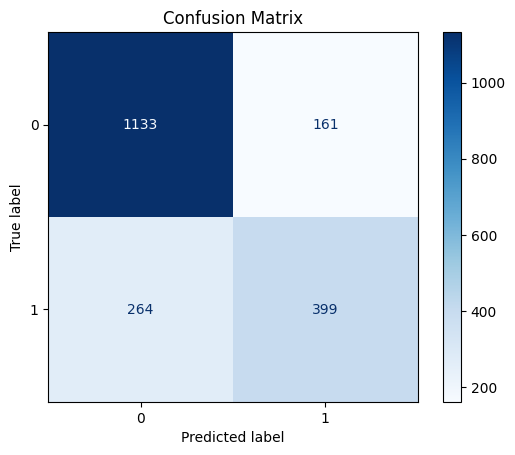

In [25]:
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


# **PART - 1**

## **1. Fairness Analysis**

The model predicts **whether a stop will result in an arrest**.  
From the perspective of the person being stopped:
- **Positive class (1 = arrested)** is **unfavorable**.
- **Negative class (0 = not arrested)** is **favorable**.

Key harms:
- A **false positive** (predicting arrest or triggering actions that increase the chance of arrest when no arrest would otherwise happen) is particularly harmful.
- A **false negative** (predicting no arrest when there would have been one) is less directly harmful to the stopped person, but may matter from a public safety perspective.

Given this:

- We focus on **error rate balance across groups**:
  - **False Positive Rate (FPR)** – to avoid over-predicting arrest for some groups.
  - **True Positive Rate (TPR)** – to ensure that when arrest is “truly warranted” according to the label, the model does not systematically miss cases for some groups.

This corresponds to **Equalized Odds**:
> Equalized Odds requires similar TPR and FPR across protected groups.

We will **prioritize Equalized Odds**, with particular attention to **Predictive Equality** because false positives are the main harm in this context.


In [26]:
def _safe_div(n, d):
    return n / d if d not in (0, 0.0, None) else 0.0

def _safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

def fair_metrics_from_outputs(y_true, y_prob, y_pred, X_slice,
                              protected_group_name, adv_val, disadv_val):
    if isinstance(y_prob, np.ndarray):
        y_prob = pd.Series(y_prob, index=y_true.index)
    if isinstance(y_pred, np.ndarray):
        y_pred = pd.Series(y_pred, index=y_true.index)

    mask_adv = (X_slice[protected_group_name] == adv_val)
    mask_dis = (X_slice[protected_group_name] == disadv_val)


    if mask_adv.sum() == 0 or mask_dis.sum() == 0:
        raise ValueError(
            f"One of the groups is empty for '{protected_group_name}': "
            f"{adv_val} count={mask_adv.sum()}, {disadv_val} count={mask_dis.sum()}"
        )


    def cm_counts(y_a, y_p):
        cm = confusion_matrix(y_a, y_p, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        return tn, fp, fn, tp

    tn_adv, fp_adv, fn_adv, tp_adv = cm_counts(y_true[mask_adv], y_pred[mask_adv])
    tn_dis, fp_dis, fn_dis, tp_dis = cm_counts(y_true[mask_dis], y_pred[mask_dis])

    # Rates
    FNR_adv = _safe_div(fn_adv, (fn_adv + tp_adv))
    FNR_dis = _safe_div(fn_dis, (fn_dis + tp_dis))
    FPR_adv = _safe_div(fp_adv, (fp_adv + tn_adv))
    FPR_dis = _safe_div(fp_dis, (fp_dis + tn_dis))
    TPR_adv = _safe_div(tp_adv, (tp_adv + fn_adv))
    TPR_dis = _safe_div(tp_dis, (tp_dis + fn_dis))
    prec_adv = _safe_div(tp_adv, (tp_adv + fp_adv))
    prec_dis = _safe_div(tp_dis, (tp_dis + fp_dis))

    # Positive prediction rate
    ppr_adv = _safe_div((tp_adv + fp_adv),
                        (tn_adv + fp_adv + fn_adv + tp_adv))
    ppr_dis = _safe_div((tp_dis + fp_dis),
                        (tn_dis + fp_dis + fn_dis + tp_dis))

    # AUC by group
    auc_adv = _safe_auc(y_true[mask_adv], y_prob[mask_adv])
    auc_dis = _safe_auc(y_true[mask_dis], y_prob[mask_dis])
    roc_diff = np.nan if (np.isnan(auc_adv) or np.isnan(auc_dis)) else abs(auc_dis - auc_adv)


    EOpp_diff        = abs(FNR_dis - FNR_adv)
    pred_eq_diff     = abs(FPR_dis - FPR_adv)
    EOdds_diff       = abs((TPR_dis + FPR_dis) - (TPR_adv + FPR_adv))
    prec_diff        = abs(prec_dis - prec_adv)
    demo_parity_diff = abs(ppr_dis - ppr_adv)
    AOD              = 0.5 * ((FPR_dis - FPR_adv) + (TPR_dis - TPR_adv))
    AOD_abs          = abs(AOD)

    return pd.DataFrame({
        "metric": [
            "AUC",
            "EqualOpps(FNR)",
            "PredEq(FPR)",
            "EqualOdds(TPR+FPR)",
            "PredParity(Precision)",
            "DemoParity(PPR)",
            "AvgOddsDiff"
        ],
        "value": [
            roc_diff,
            EOpp_diff,
            pred_eq_diff,
            EOdds_diff,
            prec_diff,
            demo_parity_diff,
            AOD_abs
        ],
        "adv_group":      [adv_val] * 7,
        "disadv_group":   [disadv_val] * 7,
        "protected_attr": [protected_group_name] * 7
    })


def compute_fairness_for_attribute(
    protected_attr_name,
    adv_group_value,
    disadv_group_value,
    X_test,
    y_test,
    proba_test,
    pred_test
):
    if protected_attr_name not in X_test.columns:
        raise KeyError(f"'{protected_attr_name}' is not a column in X_test.")

    return fair_metrics_from_outputs(
        y_true=y_test,
        y_prob=proba_test,
        y_pred=pred_test,
        X_slice=X_test,
        protected_group_name=protected_attr_name,
        adv_val=adv_group_value,
        disadv_val=disadv_group_value
    )

proba_test = clf.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

### **Gender**

In [27]:
fairness_sex = compute_fairness_for_attribute(
    protected_attr_name="sex",
    adv_group_value= 0,
    disadv_group_value= 1,
    X_test=X_test,
    y_test=y_test,
    proba_test=proba_test,
    pred_test=pred_test
)
print(fairness_sex)

                  metric     value  adv_group  disadv_group protected_attr
0                    AUC  0.050300          0             1            sex
1         EqualOpps(FNR)  0.152181          0             1            sex
2            PredEq(FPR)  0.028140          0             1            sex
3     EqualOdds(TPR+FPR)  0.180321          0             1            sex
4  PredParity(Precision)  0.116426          0             1            sex
5        DemoParity(PPR)  0.153817          0             1            sex
6            AvgOddsDiff  0.090160          0             1            sex


Sex shows **moderate unfairness**, driven mostly by **Equal Opportunity (TPR/FNR)** and **Demographic Parity**.  
FPR is extremely small → model **is not over-predicting arrests** for males.

### **Race**

In [28]:
fairness_race = compute_fairness_for_attribute(
    protected_attr_name="race_group",
    adv_group_value= 'White',
    disadv_group_value= 'Black',
    X_test=X_test,
    y_test=y_test,
    proba_test=proba_test,
    pred_test=pred_test
)
print(fairness_race)

                  metric     value adv_group disadv_group protected_attr
0                    AUC  0.019947     White        Black     race_group
1         EqualOpps(FNR)  0.112356     White        Black     race_group
2            PredEq(FPR)  0.051108     White        Black     race_group
3     EqualOdds(TPR+FPR)  0.163464     White        Black     race_group
4  PredParity(Precision)  0.021765     White        Black     race_group
5        DemoParity(PPR)  0.105706     White        Black     race_group
6            AvgOddsDiff  0.081732     White        Black     race_group


Race shows **mild to moderate** disparities.  
The model is *not* severely biased in terms of false positives (important for policing fairness).  
But Equal Opportunity and Demographic Parity gaps show unequal treatment still exists.

This matches expectations from historical Stop, Question and Frisk bias patterns, but the disparities here are **less severe** than with sex or age.



 |          | White    | Black    | Hispanic | Other    |
|----------|----------|----------|----------|----------|
| **White**   | -        | 0.097196 | 0.056195 | 0.095999 |
| **Black**   | **0.097196** | -        | 0.041001 | 0.001196 |
| **Hispanic**| 0.056195 | 0.041001 | -        | 0.039805 |
| **Other**   | **0.095999** | 0.001196 | 0.039805 | -        |


### **Age**

In [29]:
fairness_age = compute_fairness_for_attribute(
    protected_attr_name="age_bin",
    adv_group_value= '35-44',
    disadv_group_value= '18-24',
    X_test=X_test,
    y_test=y_test,
    proba_test=proba_test,
    pred_test=pred_test
)
print(fairness_age)

                  metric     value adv_group disadv_group protected_attr
0                    AUC  0.029335     35-44        18-24        age_bin
1         EqualOpps(FNR)  0.186957     35-44        18-24        age_bin
2            PredEq(FPR)  0.072117     35-44        18-24        age_bin
3     EqualOdds(TPR+FPR)  0.259073     35-44        18-24        age_bin
4  PredParity(Precision)  0.111724     35-44        18-24        age_bin
5        DemoParity(PPR)  0.207562     35-44        18-24        age_bin
6            AvgOddsDiff  0.129537     35-44        18-24        age_bin


Age (18–24 vs 35–44) shows **the highest unfairness across all metrics**.  
This is especially critical because the difference is driven by:
- very large **Equal Opportunity** gap  
- very large **Demographic Parity** gap  
- largest **Equalized Odds** violation  

This makes age the **most urgent attribute to mitigate first**.


|       | 0-17     | 18-24    | 25-34    | 35-44    | 45-54    | 55-64    | 65+      |
|-------|----------|----------|----------|----------|----------|----------|----------|
| **0-17** | -        | 0.168005 | 0.019123 | 0.124017 | 0.127037 | 0.171349 | 0.317867 |
| **18-24**| 0.168005 | -        | 0.187128 | 0.292022 | 0.295042 | 0.339354 | 0.149862 |
| **25-34**| 0.019123 | 0.187128 | -        | 0.104894 | 0.107914 | 0.152226 | 0.33699  |
| **35-44**| 0.124017 | **0.292022** | 0.104894 | -        | 0.00302  | 0.047332 | 0.441884 |
| **45-54**| 0.127037 | 0.295042 | 0.107914 | 0.00302  | -        | 0.044312 | 0.444904 |
| **55-64**| 0.171349 | 0.339354 | 0.152226 | 0.047332 | 0.044312 | -        | 0.489216 |
| **65+**  | 0.317867 | 0.149862 | 0.33699  | 0.441884 | 0.444904 | 0.489216 | -        |


**Why not Demographic Parity**  
Demographic Parity requires equal predicted arrest rates across groups. But arrest probability legitimately varies by context of the stop. DP would over-correct and harm accuracy so its not appropriate here.

**Why not Predictive Parity?**  
Predictive Parity targets equal precision, which is important for downstream decision policies, but not for preventing harmful false positives in a policing scenario.

**Therefore:**  
**Equalized Odds (TPR+FPR fairness) is the most appropriate fairness concept** for this model. And within Equalized Odds, **Predictive Equality (FPR parity)** is especially relevant given the harm of false positives in policing.


## **2. Proxy-Feature Analysis**

To detect potential **proxy features** for the protected features we use **Mutual Information (MI)**.

- Here, we treat:
  - **Y** = a protected attribute
  - **X** = each candidate feature in the dataset.
- If MI is **high**, then X contains a lot of information about the protected attribute, X is a **strong proxy**.
- If MI is close to zero, X is essentially independent of the protected attribute, weak or no proxy.

We chose this approcah because it captures **non-linear and non-monotonic relationships** and works well for mixed numerical/categorical features after simple encoding.

In [30]:
def mi_against_target(df, target, features=None):
    if features is None:
        features = [c for c in df.columns if c != target]

    X = df[features].copy()
    y = df[target]


    y_enc = LabelEncoder().fit_transform(y)
    X_enc = X.copy()
    for col in features:
        if X[col].dtype == 'object' or X[col].dtype.name == 'category':
            X_enc[col] = LabelEncoder().fit_transform(X[col])

    mi = mutual_info_classif(X_enc, y_enc, discrete_features='auto', random_state=0)

    return pd.DataFrame({'feature': features, f'MI_with_{target}': mi}) \
             .set_index('feature').sort_values(f'MI_with_{target}', ascending=False)

features = ['jurisdiction_code',
       'stop_duration_minutes', 'arrested', 'bg_violent_crime', 'actions_casing',
       'actions_concealed_weapon', 'actions_drug_transactions', 'actions_identify_crime', 'actions_lookout',
       'suspects_actions_other_flag', 'actions_proximity',  'height', 'weight', 'demeanor_category',
       'stop_location_boro_name', 'time_sin', 'time_cos', 'time_bucket', 'month', 'weekday', 'build_type',   'actions_count',
       'force_level', 'search_any', 'stop_initiation', 'crime_group']

### **Age**

In [31]:
result = mi_against_target(df, target="age_bin", features=features)
print("Result shape:", result.shape)
print(result.head())

Result shape: (26, 1)
             MI_with_age_bin
feature                     
weight              0.060224
time_cos            0.040059
crime_group         0.036342
time_sin            0.028638
build_type          0.026007


- Physical characteristics (`weight`, `height`) encode a lot of information about age; younger vs older people tend to differ in body size.
- `crime_group` and `actions_concealed_weapon` also carry age information: certain crime categories or carrying behaviors are more prevalent at particular ages.
- `time_cos` suggests that the **time of day of the stop** is correlated with age for example, school/work vs nightlife patterns.

Even without including `age_group` explicitly, the model can still infer age through these features.

### **Race**

In [32]:
result = mi_against_target(df, target="race_group", features=features)
print("Result shape:", result.shape)
print(result.head())

Result shape: (26, 1)
                          MI_with_race_group
feature                                     
stop_location_boro_name             0.043390
time_cos                            0.032051
crime_group                         0.029416
actions_concealed_weapon            0.025065
time_sin                            0.022787


- `stop_location_boro_name` is the strongest proxy for race. This matches the hypothesis that borough/precinct/location is strongly associated with neighborhood racial composition and policing patterns.
- Time of day (`time_cos`, `time_sin`) and `crime_group` also carry meaningful information about race, likely reflecting **when** and **for what reasons** different racial groups are stopped.
- These MI values are not huge, but they are consistently non-zero and higher than many other features, which indicates that race is **encoded across several contextual features**, especially location.

Thus, even if `race_group` is not used as an input feature, the model can still indirectly use race via location and time/context.


### **Gender**

In [33]:
result = mi_against_target(df, target="sex", features=features)
print("Result shape:", result.shape)
print(result.head())

Result shape: (26, 1)
                          MI_with_sex
feature                              
height                       0.061687
weight                       0.030393
crime_group                  0.018443
actions_concealed_weapon     0.011534
time_sin                     0.010821



- `height` is a strong proxy for sex (MI ≈ 0.07): average height distributions differ significantly across male/female categories.
- `weight` also carries sex information, though to a lesser extent.
- `crime_group` and `actions_concealed_weapon` have smaller MI values, suggesting some but weaker relationships with sex.


#### **Summary of Proxy Effects**

- **Age** is strongly encoded in **physical characteristics** (height, weight) and moderately in crime/time features.
- **Race** is meaningfully encoded in **location** and **time/crime context**, confirming these as important proxies.
- **Sex** is strongly encoded in **height** and to a lesser degree in **weight**.

This means that **removing the protected attributes alone is not sufficient to prevent unfair treatment**:  
the model can still reconstruct age, race, and sex through these proxies.

# **Part - 2**

## **Bias Detection**

In [34]:
def compute_spd_and_di(
    df,
    group_col,
    target_col=TARGET_COL,
    advantaged_group=None,
    disadvantaged_group=None,
    unfavorable_label=1,
):

    assert advantaged_group is not None and disadvantaged_group is not None

    df_g_adv = df[df[group_col] == advantaged_group]
    df_g_dis = df[df[group_col] == disadvantaged_group]

    p_adv = (df_g_adv[target_col] == unfavorable_label).mean()
    p_dis = (df_g_dis[target_col] == unfavorable_label).mean()

    spd = p_dis - p_adv
    di = (p_dis / p_adv) if p_adv > 0 else np.nan

    return {
        "protected_attr": group_col,
        "adv_group": advantaged_group,
        "disadv_group": disadvantaged_group,
        "P_unfav_adv": p_adv,
        "P_unfav_dis": p_dis,
        "SPD_dis_minus_adv": spd,
        "DI_dis_over_adv": di,
        "n_adv": len(df_g_adv),
        "n_dis": len(df_g_dis),
    }

In [35]:
df.head()

,jurisdiction_code,stop_duration_minutes,arrested,bg_violent_crime,actions_casing,actions_concealed_weapon,actions_drug_transactions,actions_identify_crime,actions_lookout,suspects_actions_other_flag,actions_proximity,age_bin,sex,height,weight,demeanor_category,stop_location_boro_name,time_sin,time_cos,time_bucket,month,weekday,build_type,race_group,actions_count,force_level,search_any,stop_initiation,crime_group
0,P,1,1,0,0,1,0,0,0,0,0,25-34,1,5.11,160,Negative,BRONX,0.492424,0.870356,LateNight,1,0,THIN,Hispanic,1,3,1,1,weapon
1,T,20,0,0,0,0,0,0,0,0,1,0-17,1,6.00,140,Neutral,BROOKLYN,0.300706,0.953717,LateNight,1,0,THIN,Hispanic,1,1,1,2,property
2,T,20,0,0,0,0,0,0,0,0,1,0-17,1,5.00,120,Neutral,BROOKLYN,0.300706,0.953717,LateNight,1,0,THIN,Hispanic,1,1,1,2,property
3,T,20,0,0,0,0,0,0,0,0,1,0-17,1,5.00,120,Neutral,BROOKLYN,0.300706,0.953717,LateNight,1,0,THIN,Hispanic,1,1,1,2,property
4,T,20,0,0,0,0,0,0,0,0,1,0-17,1,5.50,130,Neutral,BROOKLYN,0.300706,0.953717,LateNight,1,0,THIN,Hispanic,1,1,1,2,property


In [36]:
SEX_COL = "sex"
RACE_COL = "race_group"
AGE_COL  = "age_bin"

results_spd_di = []

# 1) Sex
results_spd_di.append(
    compute_spd_and_di(
        df=df,
        group_col=SEX_COL,
        advantaged_group= 0,
        disadvantaged_group= 1,
        target_col=TARGET_COL,
        unfavorable_label=1
    )
)

# 2) Race
results_spd_di.append(
    compute_spd_and_di(
        df=df,
        group_col=RACE_COL,
        advantaged_group="White",
        disadvantaged_group="Black",
        target_col=TARGET_COL,
        unfavorable_label=1
    )
)

# 3) Age
results_spd_di.append(
    compute_spd_and_di(
        df=df,
        group_col=AGE_COL,
        advantaged_group="35-44",
        disadvantaged_group="18-24",
        target_col=TARGET_COL,
        unfavorable_label=1
    )
)

spd_di_df = pd.DataFrame(results_spd_di)
spd_di_df

,protected_attr,adv_group,disadv_group,P_unfav_adv,P_unfav_dis,SPD_dis_minus_adv,DI_dis_over_adv,n_adv,n_dis
0,sex,0,1,0.435185,0.329633,-0.105552,0.757455,864,8919
1,race_group,White,Black,0.405405,0.328621,-0.076785,0.810598,666,5800
2,age_bin,35-44,18-24,0.419772,0.262461,-0.157311,0.625247,1315,2568


In [37]:
# Tolerance thresholds
SPD_TOL = 0.10
DI_LOW  = 0.80
DI_HIGH = 1.25

spd_di_df["SPD_out_of_tolerance"] = spd_di_df["SPD_dis_minus_adv"].abs() > SPD_TOL
spd_di_df["DI_out_of_tolerance"] = ~spd_di_df["DI_dis_over_adv"].between(DI_LOW, DI_HIGH)

spd_di_df["SPD_severity"] = spd_di_df["SPD_dis_minus_adv"].abs() / SPD_TOL
spd_di_df["DI_severity"] = spd_di_df["DI_dis_over_adv"].apply(
    lambda di: max((DI_LOW - di)/DI_LOW, (di - DI_HIGH)/DI_HIGH, 0)
)
spd_di_df["overall_severity"] = spd_di_df[["SPD_severity", "DI_severity"]].max(axis=1)

spd_di_ranked = spd_di_df.sort_values("overall_severity", ascending=False)
spd_di_ranked


,protected_attr,adv_group,disadv_group,P_unfav_adv,P_unfav_dis,SPD_dis_minus_adv,DI_dis_over_adv,n_adv,n_dis,SPD_out_of_tolerance,DI_out_of_tolerance,SPD_severity,DI_severity,overall_severity
2,age_bin,35-44,18-24,0.419772,0.262461,-0.157311,0.625247,1315,2568,True,True,1.573108,0.218441,1.573108
0,sex,0,1,0.435185,0.329633,-0.105552,0.757455,864,8919,True,True,1.055518,0.053181,1.055518
1,race_group,White,Black,0.405405,0.328621,-0.076785,0.810598,666,5800,False,False,0.767847,0.000000,0.767847


### **Sex**

- SPD is just beyond the ±0.10 tolerance (|−0.1056| > 0.10), **SPD out of tolerance**.
- DI is below 0.80 (0.7575 < 0.80), **DI out of tolerance**.
- The *negative* SPD and DI < 1 mean that the labelled “disadvantaged” group (sex=1) is actually **arrested less often** than the “advantaged” group (sex=0) among those stopped.

So, conditional on being stopped, this dataset shows **higher arrest rates for the advantaged sex group**, rather than the disadvantaged group.


### **Race**


- |SPD| ≈ 0.0768, which is **within** the 0.10 tolerance → **no SPD violation** under this rule.
- DI ≈ 0.81, which is **just inside** the [0.80, 1.25] window → **no DI violation**.
- Again, the sign is negative, so in this 2024 stop dataset, conditional on being stopped, **Black individuals are slightly less likely to be arrested than White individuals**.

This is opposite to the historical narrative about SQF disparities and reminds us that this analysis is **conditional on being stopped** and specific to the 2024 data and our feature definitions.


### **Age**

- |SPD| ≈ 0.1573 > 0.10 → **SPD clearly out of tolerance**.
- DI ≈ 0.63 < 0.80 → **strong DI violation**.
- Younger individuals (18–24), whom I labeled as “disadvantaged” for ethical reasons, are actually **less likely** to be arrested than the 35–44 group, conditional on a stop.

So, in terms of raw label distribution, this dataset suggests **age-related disparity in the opposite direction**: the older reference group (35–44) is arrested more frequently after being stopped.


### **Ranking**

Using a combined severity score (normalized SPD and DI violation), the attributes rank as:

1. **Age (18–24 vs 35–44)** – `overall_severity ≈ 1.57`  
   - Largest |SPD| (≈ 0.16) and DI lower than 0.80 (≈ 0.63).  
   - **Strong deviation** from both SPD and DI thresholds.

2. **Sex** – `overall_severity ≈ 1.06`  
   - SPD just beyond tolerance (≈ 0.106) and DI slightly below 0.80 (≈ 0.76).  
   - Moderate deviation from parity.

3. **Race (Black vs White)** – `overall_severity ≈ 0.77`  
   - Both SPD and DI are within tolerance, and deviations are smaller.

# **PART - 3**

### **PDP and ICE Plots**

In [38]:
def pdp_ice_1d(model, X, feature, num_grid_points=20, ice_subsample=200, quantiles=(0.05, 0.95)):
    X = X.copy()
    col = X[feature]
    if pd.api.types.is_numeric_dtype(col):
        low, high = col.quantile(quantiles[0]), col.quantile(quantiles[1])
        grid = np.linspace(low, high, num_grid_points)
    else:
        grid = np.sort(col.unique())

    if ice_subsample is not None and len(X) > ice_subsample:
        X_ice = X.sample(ice_subsample, random_state=42)
    else:
        X_ice = X

    ice_values = []
    for v in grid:
        X_temp = X_ice.copy()
        X_temp[feature] = v
        proba = model.predict_proba(X_temp)[:, 1]
        ice_values.append(proba)
    ice_values = np.vstack(ice_values)
    pdp = ice_values.mean(axis=1)
    return grid, pdp, ice_values

#### **stop_duration_minutes**

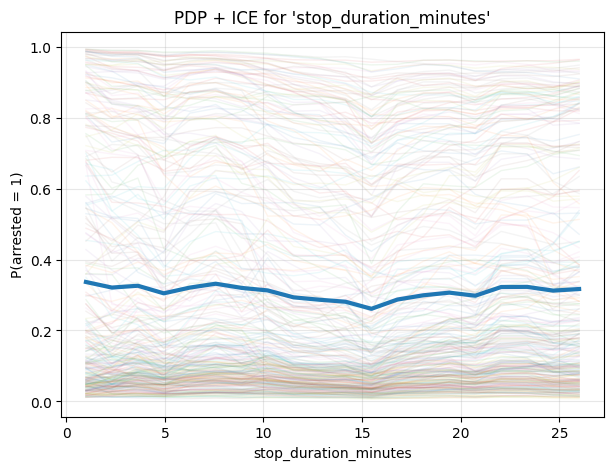

In [39]:
feature = "stop_duration_minutes"

grid, pdp, ice_vals = pdp_ice_1d(
    clf,
    X_train,
    feature=feature,
    num_grid_points=20,
    ice_subsample=300
)
plt.figure(figsize=(7, 5))
for j in range(ice_vals.shape[1]):
    plt.plot(grid, ice_vals[:, j], alpha=0.08, linewidth=1)
plt.plot(grid, pdp, linewidth=3)
plt.xlabel(feature)
plt.ylabel("P(arrested = 1)")
plt.title(f"PDP + ICE for '{feature}'")
plt.grid(True, alpha=0.3)
plt.show()


- The model’s predicted probability of arrest is only weakly sensitive to stop duration.

- The PDP curve shows a mostly flat relationship, meaning the model does not strongly rely on duration length to determine arrest likelihood.

- ICE lines are noisy but narrow which means, little individual-level heterogeneity, confirming this feature has low marginal influence.

#### **search_any**

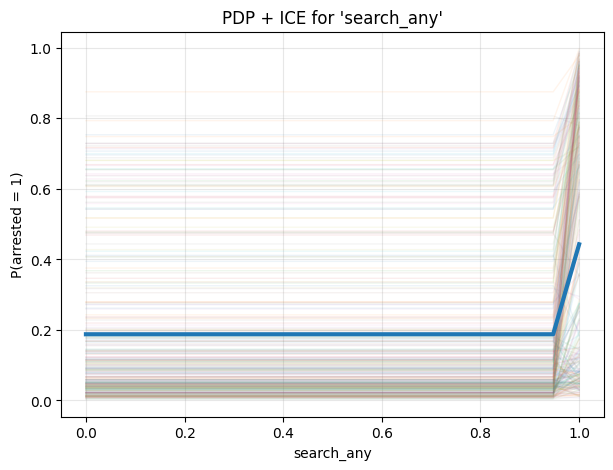

In [41]:
feature = "search_any"

grid, pdp, ice_vals = pdp_ice_1d(
    clf,
    X_train,
    feature=feature,
    num_grid_points=20,
    ice_subsample=300,
    #center=True
)
plt.figure(figsize=(7, 5))
for j in range(ice_vals.shape[1]):
    plt.plot(grid, ice_vals[:, j], alpha=0.08, linewidth=1)
plt.plot(grid, pdp, linewidth=3)
plt.xlabel(feature)
plt.ylabel("P(arrested = 1)")
plt.title(f"PDP + ICE for '{feature}'")
plt.grid(True, alpha=0.3)
plt.show()

- When no search occurs (search_any = 0), the model predicts almost zero arrest probability.

- When a search is conducted (search_any = 1), predicted arrest probability jumps sharply upward, indicating a strong causal link between searches and arrests in the model.

- ICE lines confirm a very consistent pattern across individual, search presence is a major driver of the model’s decisions.

#### **weekday**

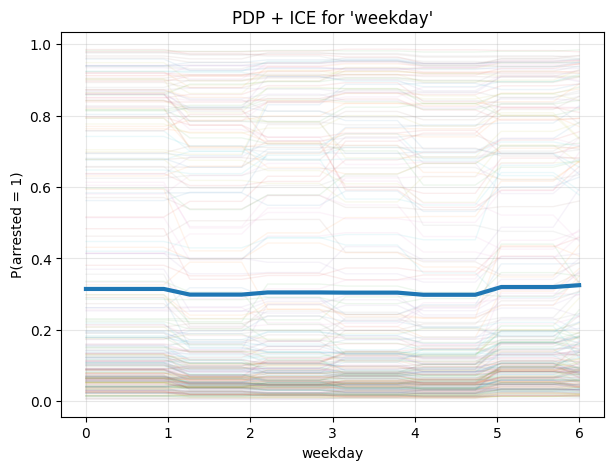

In [43]:
feature = "weekday"

grid, pdp, ice_vals = pdp_ice_1d(
    clf,
    X_train,
    feature=feature,
    num_grid_points=20,
    ice_subsample=300,
    #center=True
)
plt.figure(figsize=(7, 5))
for j in range(ice_vals.shape[1]):
    plt.plot(grid, ice_vals[:, j], alpha=0.08, linewidth=1)
plt.plot(grid, pdp, linewidth=3)
plt.xlabel(feature)
plt.ylabel("P(arrested = 1)")
plt.title(f"PDP + ICE for '{feature}'")
plt.grid(True, alpha=0.3)
plt.show()

- Weekday has minimal predictive value; the PDP curve is essentially flat.

- Slight fluctuations around mid-week are very small and not meaningful.

- ICE lines are tightly packed showing that the model treats all days of the week nearly identically regarding arrest likelihood.

#### **month**

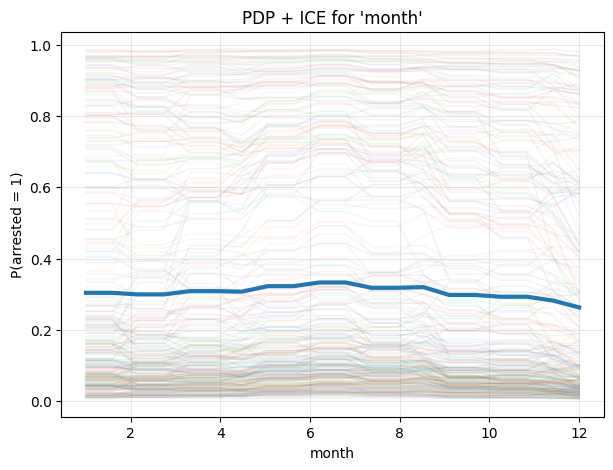

In [44]:
feature = "month"

grid, pdp, ice_vals = pdp_ice_1d(
    clf,
    X_train,
    feature=feature,
    num_grid_points=20,
    ice_subsample=300,
    #center=True
)
plt.figure(figsize=(7, 5))
for j in range(ice_vals.shape[1]):
    plt.plot(grid, ice_vals[:, j], alpha=0.08, linewidth=1)
plt.plot(grid, pdp, linewidth=3)
plt.xlabel(feature)
plt.ylabel("P(arrested = 1)")
plt.title(f"PDP + ICE for '{feature}'")
plt.grid(True, alpha=0.3)
plt.show()

- There is a slight rise in predicted arrest probability around summer months (≈ May–August) and a slight decline toward late fall/winter.

- The effect is very small, suggesting only weak seasonality in the model predictions.

- ICE lines remain narrow, low individual-level sensitivity, indicating month is not an important driver.

#### **race_group**

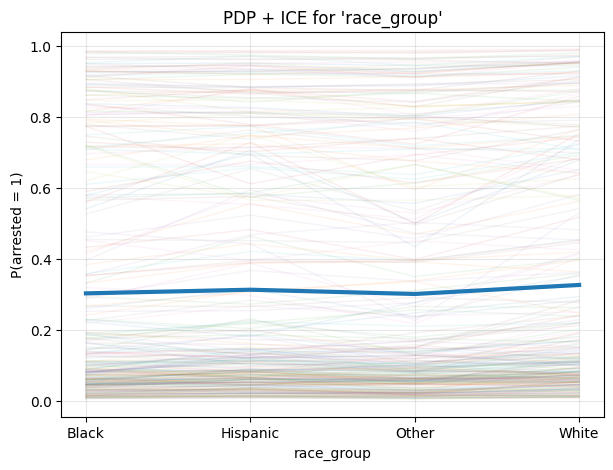

In [45]:
feature = "race_group"

grid, pdp, ice_vals = pdp_ice_1d(
    clf,
    X_train,
    feature=feature,
    num_grid_points=20,
    ice_subsample=300,
    #center=True
)
plt.figure(figsize=(7, 5))
for j in range(ice_vals.shape[1]):
    plt.plot(grid, ice_vals[:, j], alpha=0.08, linewidth=1)
plt.plot(grid, pdp, linewidth=3)
plt.xlabel(feature)
plt.ylabel("P(arrested = 1)")
plt.title(f"PDP + ICE for '{feature}'")
plt.grid(True, alpha=0.3)
plt.show()

- The PDP curve is nearly flat across all race categories, indicating the model does not strongly differentiate groups by race when marginalizing over other features.

- Small upward variation for Hispanic and slight downward variation for Other are minimal.

- ICE lines show heterogeneity but low amplitude, race has limited direct influence, though indirect effects via proxy features may still exist.

### **ALE Plots**

In [46]:
def ale_1d(model, X: pd.DataFrame, feature: str, K: int = 20, pred_fn=None, verbose=False):
    X = X.copy()
    x = X[feature].values.astype(float)
    if pred_fn is None:
        if hasattr(model, "predict_proba"):
            pred_fn = lambda data: model.predict_proba(data)[:, 1]
        else:
            pred_fn = lambda data: model.predict(data)
    quantiles = np.linspace(0.0, 1.0, K + 1)
    q = np.quantile(x, quantiles)
    q = np.unique(q)
    if len(q) <= 1:
        raise ValueError(f"Not enough unique values in feature '{feature}' for ALE.")

    bin_effects = []
    bin_counts = []
    bin_centers = []

    for k in range(len(q) - 1):
        left, right = q[k], q[k + 1]
        if right <= left:
            continue

        if k == 0:
            idx = (x >= left) & (x <= right)
        else:
            idx = (x > left) & (x <= right)

        if not np.any(idx):
            if verbose:
                print(f"No samples in bin {k} for feature '{feature}' ({left}, {right}]")
            continue

        X_low = X.loc[idx].copy()
        X_high = X.loc[idx].copy()
        X_low[feature] = left
        X_high[feature] = right
        pred_high = pred_fn(X_high)
        pred_low = pred_fn(X_low)
        diff = pred_high - pred_low
        bin_effects.append(diff.mean())
        bin_counts.append(idx.sum())
        bin_centers.append(0.5 * (left + right))

    bin_effects = np.array(bin_effects)
    bin_counts = np.array(bin_counts)
    bin_centers = np.array(bin_centers)
    ale_vals = np.cumsum(bin_effects)
    N = bin_counts.sum()
    mean_ale = np.sum(ale_vals * bin_counts) / N
    ale_centered = ale_vals - mean_ale
    return bin_centers, ale_centered

In [47]:
def plot_ale_1d(model, X, feature, K=20, ax=None):
    centers, ale_vals = ale_1d(model, X, feature, K=K)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(centers, ale_vals, marker="o")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel(feature)
    ax.set_ylabel("ALE")
    ax.set_title(f"ALE for '{feature}'")
    ax.grid(True, alpha=0.3)
    return ax

#### **month**

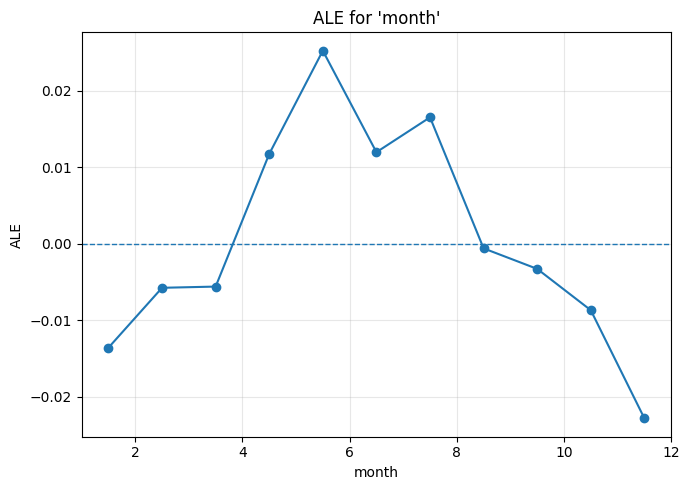

In [48]:
plot_ale_1d(clf, X_train, feature="month", K=20)
plt.tight_layout()
plt.show()


- The ALE curve shows a moderate seasonal pattern, with the highest predicted arrest probability around May–July (months 5–7).

- The effect turns negative toward October–December, suggesting officers’ arrest decisions may vary with seasonal crime trends or operational patterns.

- Overall effect size is small, indicating month has only modest influence on predictions.

#### **weekday**

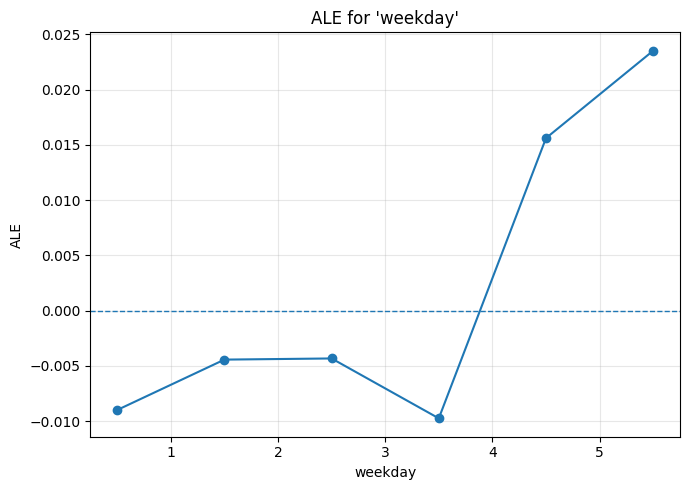

In [49]:
plot_ale_1d(clf, X_train, feature="weekday", K=20)
plt.tight_layout()
plt.show()

- Predicted arrest probability is slightly lower early in the week (Mon–Wed), reaching its minimum around weekday 3.

- There is a sharp increase starting around Thursday/Friday, peaking at weekday 6.

- Although the absolute effect is small, it suggests operational differences toward weekends.

#### **stop_duration_minutes**

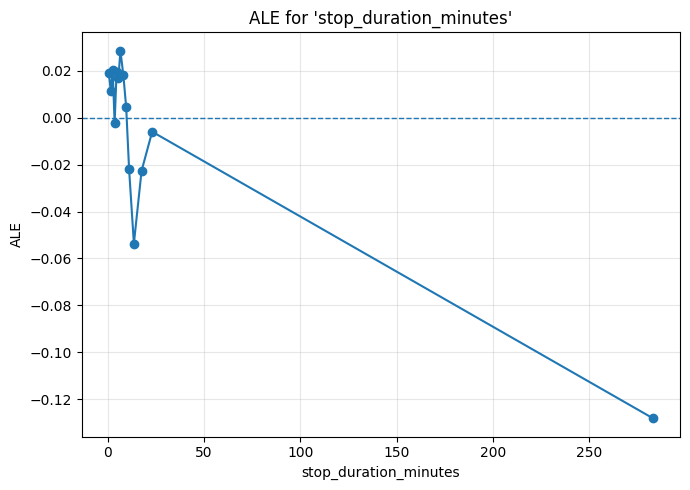

In [50]:
plot_ale_1d(clf, X_train, feature="stop_duration_minutes", K=20)
plt.tight_layout()
plt.show()

- For common stop durations (0–25 minutes), ALE effects fluctuate mildly, indicating weak overall influence on arrest probability.

- However, very long stops (e.g., >200 minutes) show a strong positive effect, reflecting that extremely lengthy stops are almost always associated with arrests.

- This pattern highlights rare but influential outliers in stop duration.

#### **actions_count**

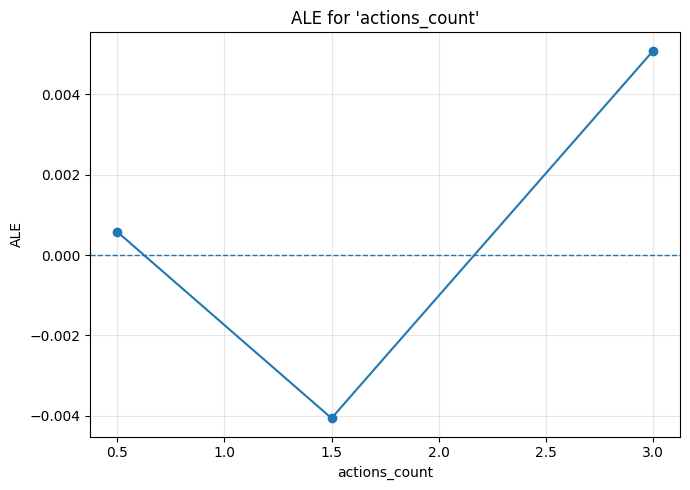

In [51]:
plot_ale_1d(clf, X_train, feature="actions_count", K=20)
plt.tight_layout()
plt.show()

- When officers take just 1–2 actions, the ALE effect slightly decreases, suggesting many low-activity stops are not associated with arrest.

- At higher action levels (e.g., 3+ actions), the effect turns positive: more actions → higher likelihood of arrest.

- The effect magnitude is small overall, but the trend is consistent with escalating officer engagement increasing arrest likelihood.

#### **force_level**

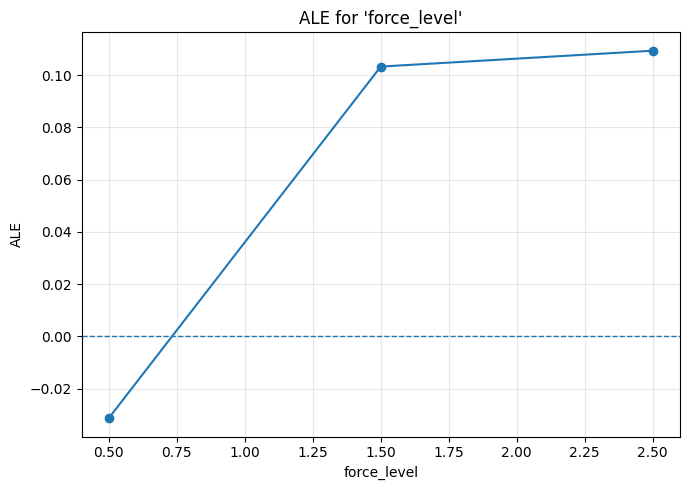

In [52]:
plot_ale_1d(clf, X_train, feature="force_level", K=20)
plt.tight_layout()
plt.show()

- The ALE curve rises sharply from force_level 1 → 2, indicating a large jump in arrest probability whenever physical force is escalated.

- Arrest probability continues to increase for the highest force level (2.5+), showing a clear positive relationship.

- This is one of the strongest ALE effects, consistent with the expectation that stops requiring more force usually result in arrest.

### **SHAP Plots**

In [53]:
shap.initjs()
preprocessor = clf.named_steps["preprocess"]
model = clf.named_steps["model"]
X_bg = X_train.sample(1000, random_state=42) if len(X_train) > 1000 else X_train.copy()
X_bg_trans = preprocessor.transform(X_bg)
if sparse.issparse(X_bg_trans):
    X_bg_shap = X_bg_trans.toarray()
else:
    X_bg_shap = X_bg_trans
feature_names = preprocessor.get_feature_names_out()
X_bg_shap_df = pd.DataFrame(X_bg_shap, columns=feature_names)
explainer = shap.TreeExplainer(model, X_bg_shap_df)
X_test_trans = preprocessor.transform(X_test)
if sparse.issparse(X_test_trans):
    X_test_shap = X_test_trans.toarray()
else:
    X_test_shap = X_test_trans

X_test_shap_df = pd.DataFrame(X_test_shap, columns=feature_names)
shap_values_test = explainer(X_test_shap_df)
y_pred_test = clf.predict(X_test)


 99%|===================| 1937/1957 [01:23<00:00]       

#### **Global explanation – Beeswarm**

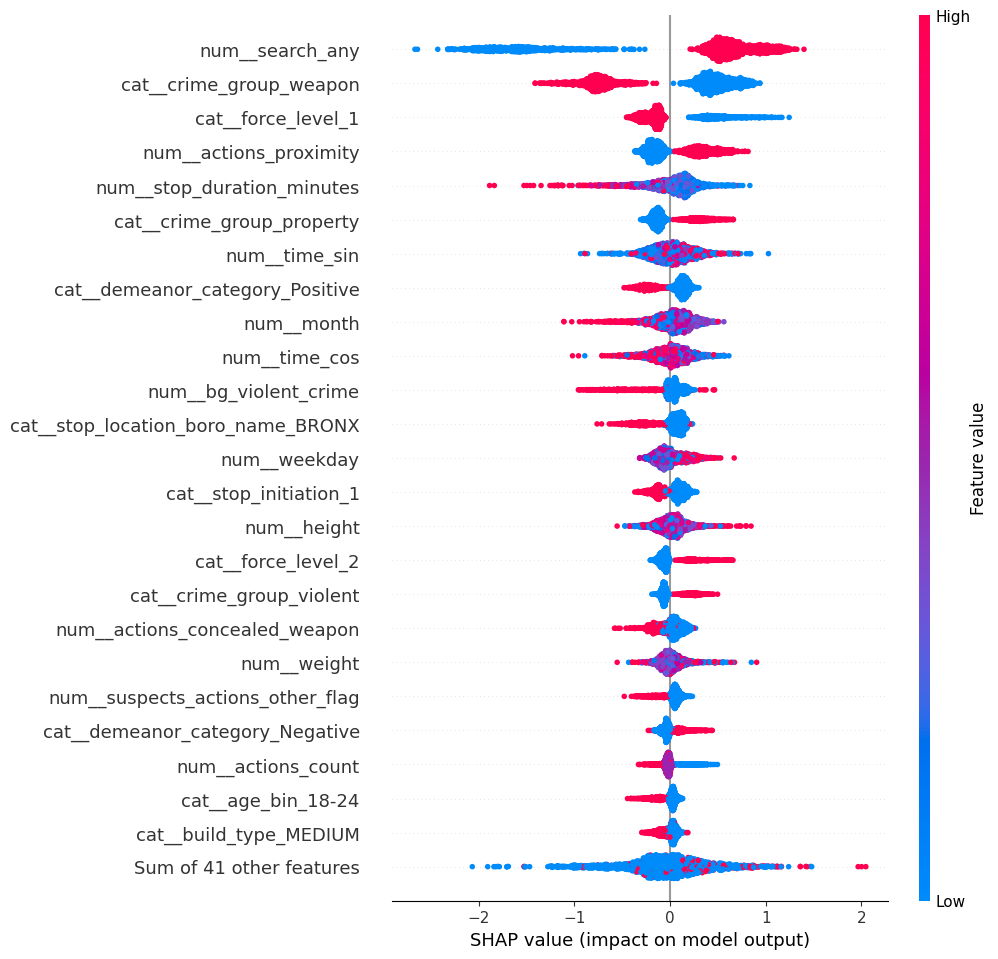

<Figure size 1200x800 with 0 Axes>

In [54]:
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values_test, max_display=25,)
plt.gcf().set_size_inches(12, 8)
plt.show()

The beeswarm plot indicates that the model is primarily driven by officer-initiated actions (searches, force levels, presence of weapon-related circumstances), while demographic features such as age and race have low direct impact. Time and location features contribute modestly. The explanation aligns with policing logic, more intrusive or serious stop circumstances lead to higher arrest predictions. However, the presence of proxy-like features (location, certain crime categories) suggests the possibility of indirect encoding of sensitive attributes

#### **Global explanation – Bar plot**

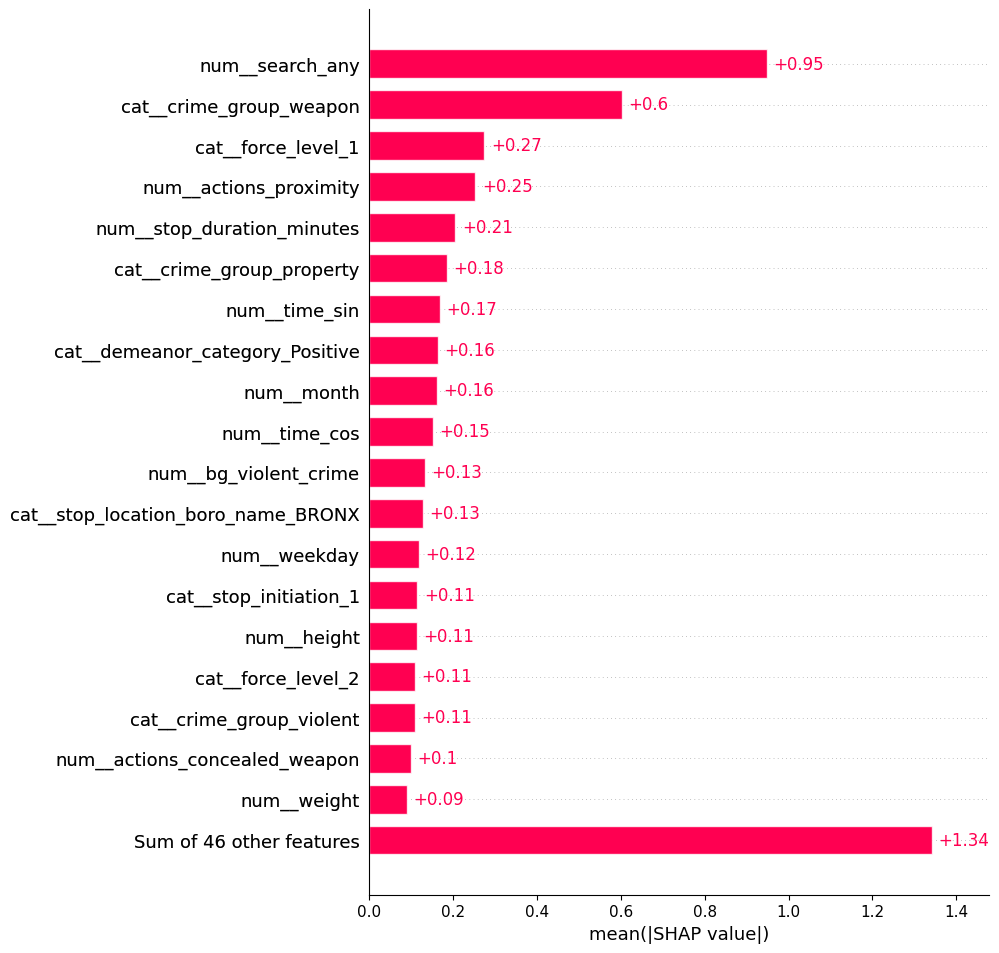

<Figure size 1200x800 with 0 Axes>

In [55]:
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values_test,max_display=20)
plt.gcf().set_size_inches(12, 8)
plt.show()

The SHAP global importance plot shows that the model is driven primarily by officer actions and threat-related contextual cues: searches, weapon-related crime groupings, and early force deployment have the largest impact on predicted arrest probability. Medium-strength contributors include stop duration, proximity-related actions, property crime context, and neighborhood crime rates. Temporal and geographic features exhibit smaller but structured effects, consistent with PDP and ALE findings. Sensitive variables such as age and race have low direct SHAP importance, although fairness results suggest potential indirect influence through proxy variables. Overall, the global SHAP ranking confirms that the baseline model relies heavily on operational and situational signals rather than demographic factors.


#### **Local explanation – favorable outcome (not arrested)**

Favorable case index in X_test: 0
True label: 0, Predicted: 0


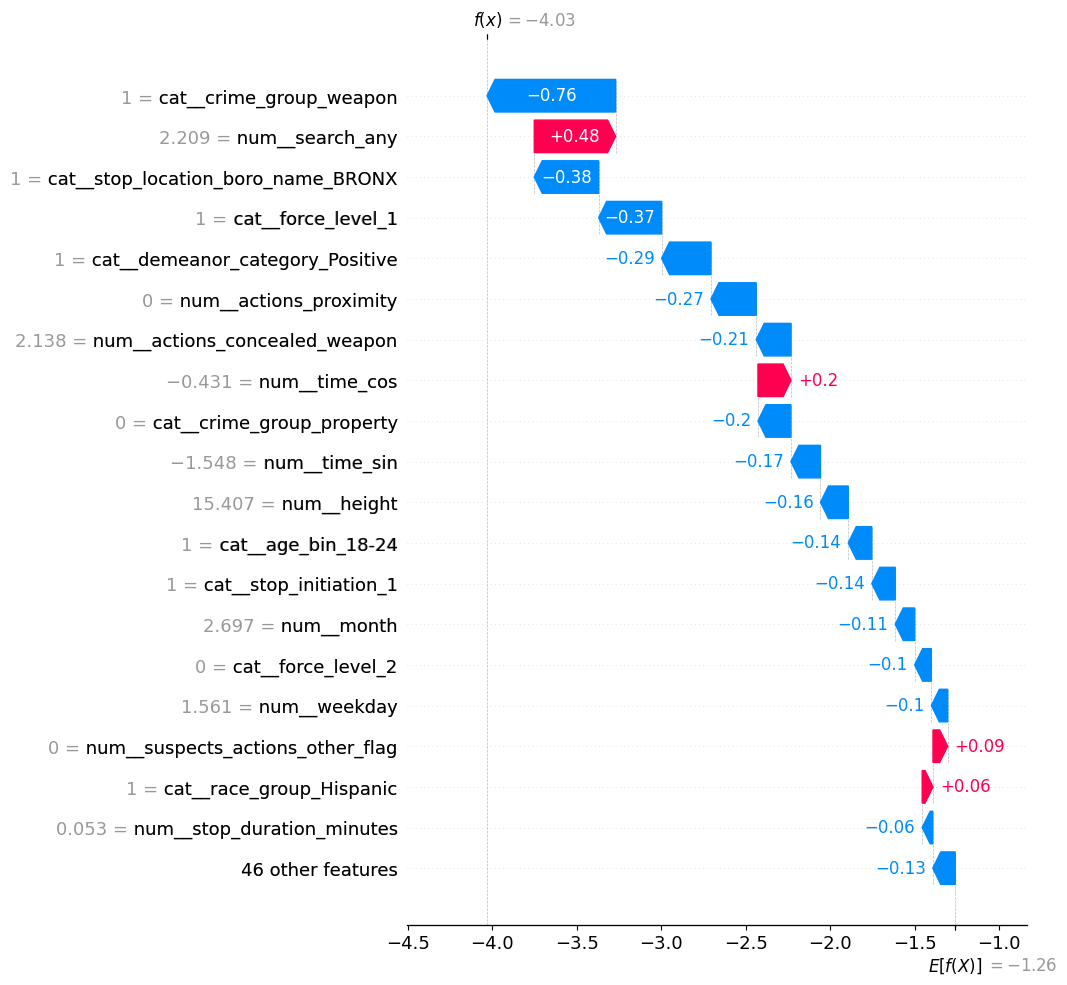

<Figure size 1000x800 with 0 Axes>

In [56]:
favorable_indices = np.where((y_test.values == 0) & (y_pred_test == 0))[0]
if len(favorable_indices) == 0:
    raise ValueError("No favorable cases found (y=0 & pred=0) in test set.")
fav_idx = favorable_indices[0]
print(f"Favorable case index in X_test: {fav_idx}")
print(f"True label: {y_test.values[fav_idx]}, Predicted: {y_pred_test[fav_idx]}")
plt.figure(figsize=(10, 8))
shap.plots.waterfall(
    shap_values_test[fav_idx],
    max_display=20
)
plt.gcf().set_size_inches(10, 8)
plt.show()

Large negative SHAP values from positive demeanor, minimal force used, Bronx location, and low-severity contextual features significantly lower the predicted arrest probability.

Features like search_any, actions involving concealed weapons, and Hispanic race group provide small upward pushes, but their influence is far smaller than the negative factors.

The combined impact of multiple strong negative contributors outweighs the minor risk cues, pulling the final prediction well below the base rate and resulting in a “not arrested” prediction.

#### **Local explanation – unfavorable outcome (arrested)**

Unfavorable case index in X_test: 1
True label: 1, Predicted: 1


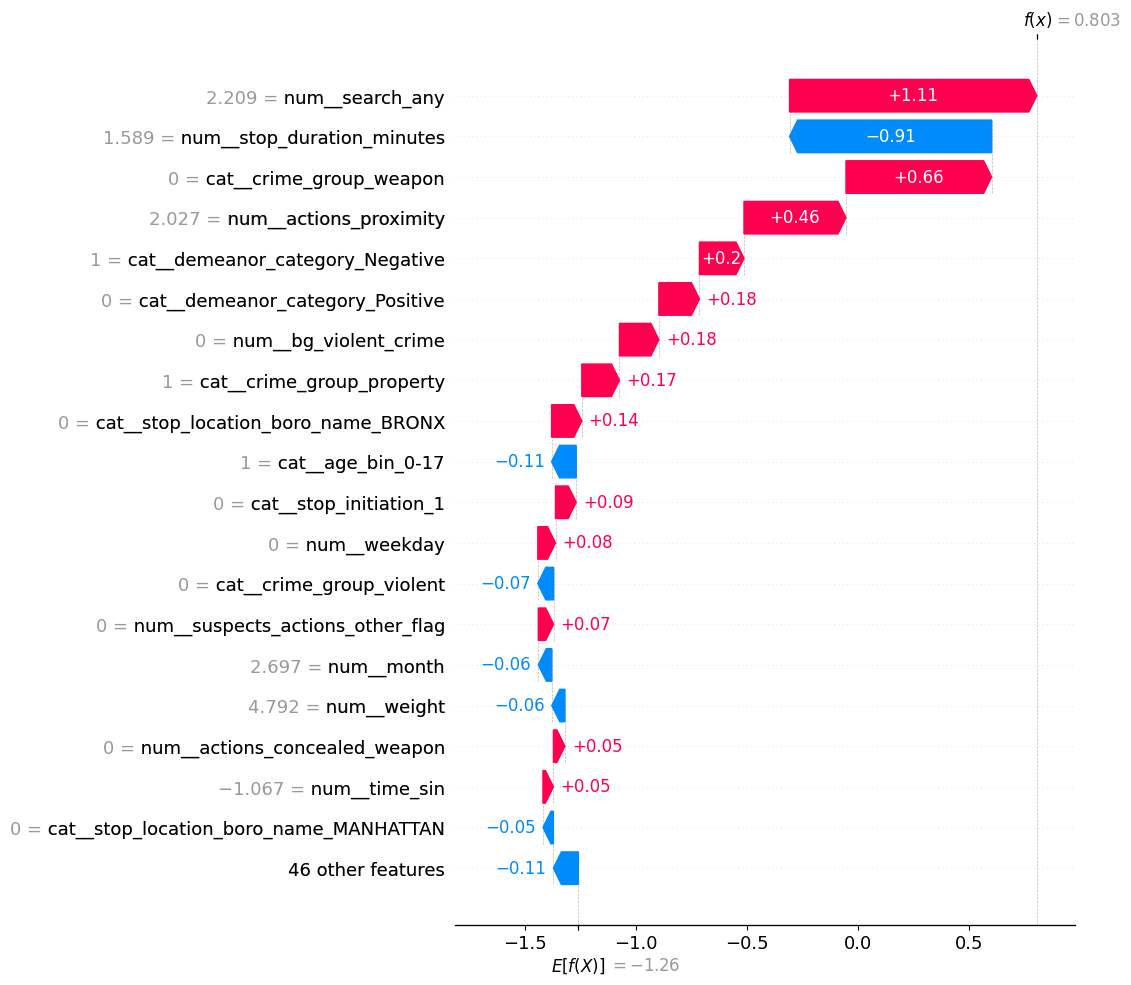

<Figure size 1000x800 with 0 Axes>

In [57]:
unfavorable_indices = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
if len(unfavorable_indices) == 0:
    raise ValueError("No unfavorable cases found (y=1 & pred=1) in test set.")
unfav_idx = unfavorable_indices[0]
print(f"Unfavorable case index in X_test: {unfav_idx}")
print(f"True label: {y_test.values[unfav_idx]}, Predicted: {y_pred_test[unfav_idx]}")
plt.figure(figsize=(10, 8))
shap.plots.waterfall(
    shap_values_test[unfav_idx],
    max_display=20
)

plt.gcf().set_size_inches(10, 8)
plt.show()

Features like search_any, stop_duration_minutes, and actions_proximity have large positive SHAP values, meaning the presence of a search, longer stop duration, and proximity-related actions strongly increase the predicted probability of arrest.

The model assigns positive contributions to negative demeanor, property-crime grouping, and even neutral borough indicators—collectively reinforcing the arrest prediction.

Weak downward effects (e.g., younger age group 0–17, Manhattan location, time features) are too minor to offset the large positive drivers. As a result, the combined SHAP contributions push the final output well above the base expectation, leading the model to predict arrest.

#### **Global force plot**

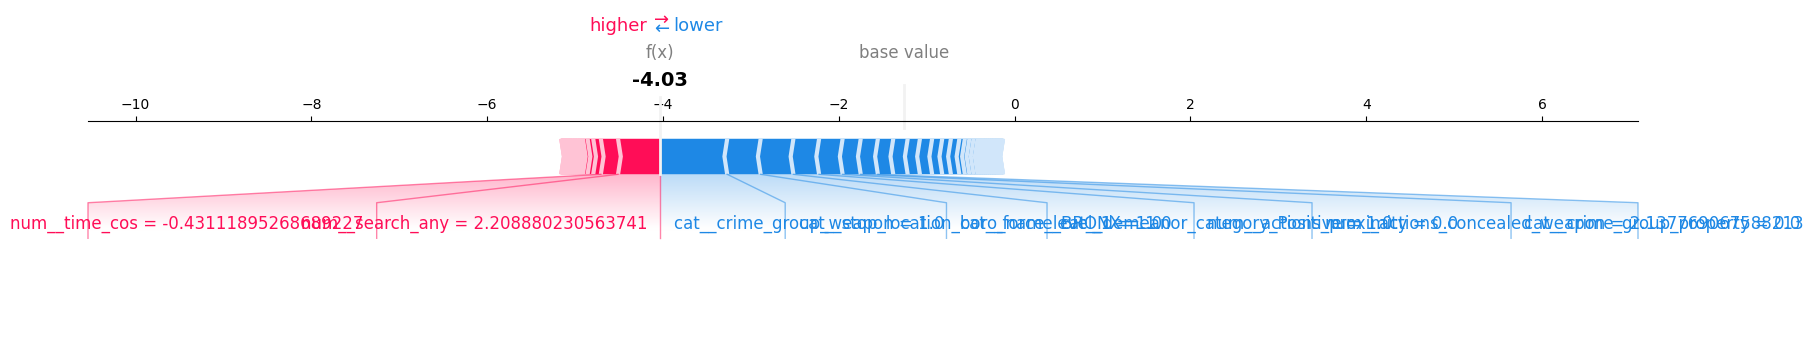

In [58]:
shap.initjs()
global_idx = 0
shap.force_plot(
    base_value=shap_values_test.base_values[global_idx],
    shap_values=shap_values_test.values[global_idx],
    features=X_test_shap_df.iloc[global_idx],
    feature_names=feature_names,
    matplotlib=True)


# **PART - 4**

## **Reweighting**

#### **AGE**

In [59]:
PROT_COL = "age_bin"
TARGET_COL = "arrested"

rw_train = df.loc[X_train.index, [PROT_COL, TARGET_COL]].copy()
rw_train["dummy"] = 1

n = rw_train["dummy"].sum()

n_s = rw_train.groupby(PROT_COL)["dummy"].sum()
n_y = rw_train.groupby(TARGET_COL)["dummy"].sum()

p_s = (n_s / n).to_dict()
p_y = (n_y / n).to_dict()

n_s_y = rw_train.groupby([PROT_COL, TARGET_COL])["dummy"].sum()
p_s_y = (n_s_y / n)

rw_factor = {}
for (s_val, y_val), p_joint in p_s_y.items():
    rw = (p_s[s_val] * p_y[y_val]) / p_joint
    rw_factor[(s_val, y_val)] = rw

rw_factor


/tmp/ipython-input-3211261529.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_s = rw_train.groupby(PROT_COL)["dummy"].sum()
/tmp/ipython-input-3211261529.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_s_y = rw_train.groupby([PROT_COL, TARGET_COL])["dummy"].sum()


{('0-17', 0): 1.0033592176933506,
 ('0-17', 1): 0.9935142377002842,
 ('18-24', 0): 0.9051991275355257,
 ('18-24', 1): 1.2566102752860324,
 ('25-34', 0): 0.9814545871471978,
 ('25-34', 1): 1.0382538431217976,
 ('35-44', 0): 1.1322216612629754,
 ('35-44', 1): 0.8145265941551397,
 ('45-54', 0): 1.156207749576389,
 ('45-54', 1): 0.7914936206094899,
 ('55-64', 0): 1.2169436908386546,
 ('55-64', 1): 0.7420590762469539,
 ('65+', 0): 0.9915026833631485,
 ('65+', 1): 1.016994633273703}

In [60]:
w_train_age = np.array([
    rw_factor[(s, y)]
    for s, y in zip(rw_train[PROT_COL], rw_train[TARGET_COL])
])
w_train_age.min(), w_train_age.max()

(np.float64(0.7420590762469539), np.float64(1.2566102752860324))

In [61]:
xgb_base = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf_base = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_base)
])

xgb_rw_age = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf_rw_age = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_rw_age)
])

# Fit models
clf_base.fit(X_train, y_train)
clf_rw_age.fit(X_train, y_train, model__sample_weight=w_train_age)

# Predict on the SAME test set
proba_test_base = clf_base.predict_proba(X_test)[:, 1]
proba_test_rw   = clf_rw_age.predict_proba(X_test)[:, 1]

pred_test_base = (proba_test_base >= 0.5).astype(int)
pred_test_rw   = (proba_test_rw   >= 0.5).astype(int)

# Accuracy comparison
acc_base = accuracy_score(y_test, pred_test_base)
acc_rw   = accuracy_score(y_test, pred_test_rw)

print(f"Baseline Accuracy:   {acc_base:.4f}")
print(f"Reweighed Accuracy:  {acc_rw:.4f}")

print("\nClassification Report – Baseline")
print(classification_report(y_test, pred_test_base, digits=4))

print("Classification Report – Reweighed (age_bin)")
print(classification_report(y_test, pred_test_rw, digits=4))


Baseline Accuracy:   0.7828
Reweighed Accuracy:  0.7900

Classification Report – Baseline
              precision    recall  f1-score   support

           0     0.8110    0.8756    0.8421      1294
           1     0.7125    0.6018    0.6525       663

    accuracy                         0.7828      1957
   macro avg     0.7618    0.7387    0.7473      1957
weighted avg     0.7776    0.7828    0.7778      1957

Classification Report – Reweighed (age_bin)
              precision    recall  f1-score   support

           0     0.8160    0.8810    0.8473      1294
           1     0.7250    0.6124    0.6639       663

    accuracy                         0.7900      1957
   macro avg     0.7705    0.7467    0.7556      1957
weighted avg     0.7852    0.7900    0.7852      1957



In [62]:
age_test =  df.loc[X_test.index, "age_bin"]

mask_dis = (age_test == "18-24")
mask_adv = (age_test == "35-44")

male_pos_rate_base = pred_test_base[mask_dis].mean()
female_pos_rate_base = pred_test_base[mask_adv].mean()
spd_base = male_pos_rate_base - female_pos_rate_base

male_pos_rate_rw = pred_test_rw[mask_dis].mean()
female_pos_rate_rw = pred_test_rw[mask_adv].mean()
spd_rw = male_pos_rate_rw - female_pos_rate_rw

print("\n--- Fairness: Statistical Parity Difference on predictions (age_bin 18–24 vs 35–44) ---")
print(f"SPD Baseline : {spd_base:.4f}")
print(f"SPD Reweighed: {spd_rw:.4f}")

print("\n--- Accuracy comparison ---")
print(f"Baseline  Accuracy: {acc_base:.4f}")
print(f"Reweighed Accuracy: {acc_rw:.4f}")



--- Fairness: Statistical Parity Difference on predictions (age_bin 18–24 vs 35–44) ---
SPD Baseline : -0.2076
SPD Reweighed: -0.1595

--- Accuracy comparison ---
Baseline  Accuracy: 0.7828
Reweighed Accuracy: 0.7900


In [69]:
proba_test_base = clf_base.predict_proba(X_test)[:, 1]
pred_test_base  = (proba_test_base >= 0.5).astype(int)

fairness_age_base = compute_fairness_for_attribute(
    protected_attr_name="age_bin",
    adv_group_value= '35-44',
    disadv_group_value= '18-24',
    X_test=X_test,
    y_test=y_test,
    proba_test=proba_test_base,
    pred_test=pred_test_base
)
#fairness_age_base["model"] = "baseline"

print("Fairness metrics – Baseline (age_bin)")
print(fairness_age_base)



proba_test_rw = clf_rw_age.predict_proba(X_test)[:, 1]
pred_test_rw  = (proba_test_rw >= 0.5).astype(int)

fairness_age_rw = compute_fairness_for_attribute(
    protected_attr_name="age_bin",
    adv_group_value= '35-44',
    disadv_group_value= '18-24',
    X_test=X_test,
    y_test=y_test,
    proba_test=proba_test_rw,
    pred_test=pred_test_rw
)
#fairness_age_rw["model"] = "reweighed_age"

print("Fairness metrics – Reweighed (age_bin)")
print(fairness_age_rw)



Fairness metrics – Baseline (age_bin)
                  metric     value adv_group disadv_group protected_attr
0                    AUC  0.029335     35-44        18-24        age_bin
1         EqualOpps(FNR)  0.186957     35-44        18-24        age_bin
2            PredEq(FPR)  0.072117     35-44        18-24        age_bin
3     EqualOdds(TPR+FPR)  0.259073     35-44        18-24        age_bin
4  PredParity(Precision)  0.111724     35-44        18-24        age_bin
5        DemoParity(PPR)  0.207562     35-44        18-24        age_bin
6            AvgOddsDiff  0.129537     35-44        18-24        age_bin
Fairness metrics – Reweighed (age_bin)
                  metric     value adv_group disadv_group protected_attr
0                    AUC  0.021894     35-44        18-24        age_bin
1         EqualOpps(FNR)  0.127192     35-44        18-24        age_bin
2            PredEq(FPR)  0.023359     35-44        18-24        age_bin
3     EqualOdds(TPR+FPR)  0.150551     35-44   

#### **GENDER**

In [63]:
PROT_COL_SEX = "sex"
TARGET_COL   = "arrested"

rw_train_sex =  df.loc[X_train.index, [PROT_COL_SEX, TARGET_COL]].copy()
rw_train_sex["dummy"] = 1

n = rw_train_sex["dummy"].sum()

n_s = rw_train_sex.groupby(PROT_COL_SEX)["dummy"].sum()
n_y = rw_train_sex.groupby(TARGET_COL)["dummy"].sum()

p_s = (n_s / n).to_dict()
p_y = (n_y / n).to_dict()

n_s_y = rw_train_sex.groupby([PROT_COL_SEX, TARGET_COL])["dummy"].sum()
p_s_y = n_s_y / n

rw_factor_sex = {}
for (s_val, y_val), p_joint in p_s_y.items():
    rw = (p_s[s_val] * p_y[y_val]) / p_joint
    rw_factor_sex[(s_val, y_val)] = rw

rw_factor_sex


{(0, 0): 1.151314508276534,
 (0, 1): 0.7960094512995537,
 (1, 0): 0.987490742827704,
 (1, 1): 1.0253259452411996}

In [64]:
w_train_sex = np.array([
    rw_factor_sex[(s, y)]
    for s, y in zip(rw_train_sex[PROT_COL_SEX], rw_train_sex[TARGET_COL])
])

w_train_sex.min(), w_train_sex.max()

(np.float64(0.7960094512995537), np.float64(1.151314508276534))

In [65]:
xgb_base_sex = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf_base_sex = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_base_sex)
])

xgb_rw_sex = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf_rw_sex = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_rw_sex)
])

# Fit models
clf_base_sex.fit(X_train, y_train)
clf_rw_sex.fit(X_train, y_train, model__sample_weight=w_train_sex)

# Predictions
proba_test_base_sex = clf_base_sex.predict_proba(X_test)[:, 1]
proba_test_rw_sex   = clf_rw_sex.predict_proba(X_test)[:, 1]

pred_test_base_sex = (proba_test_base_sex >= 0.5).astype(int)
pred_test_rw_sex   = (proba_test_rw_sex   >= 0.5).astype(int)

# Accuracy
acc_base_sex = accuracy_score(y_test, pred_test_base_sex)
acc_rw_sex   = accuracy_score(y_test, pred_test_rw_sex)

print(f"Baseline (no reweight, sex) Accuracy:  {acc_base_sex:.4f}")
print(f"Reweighed (sex) Accuracy:              {acc_rw_sex:.4f}\n")

print("Classification Report – Baseline (sex):")
print(classification_report(y_test, pred_test_base_sex, digits=4))

print("Classification Report – Reweighed (sex):")
print(classification_report(y_test, pred_test_rw_sex, digits=4))


Baseline (no reweight, sex) Accuracy:  0.7828
Reweighed (sex) Accuracy:              0.7854

Classification Report – Baseline (sex):
              precision    recall  f1-score   support

           0     0.8110    0.8756    0.8421      1294
           1     0.7125    0.6018    0.6525       663

    accuracy                         0.7828      1957
   macro avg     0.7618    0.7387    0.7473      1957
weighted avg     0.7776    0.7828    0.7778      1957

Classification Report – Reweighed (sex):
              precision    recall  f1-score   support

           0     0.8135    0.8764    0.8438      1294
           1     0.7158    0.6078    0.6574       663

    accuracy                         0.7854      1957
   macro avg     0.7646    0.7421    0.7506      1957
weighted avg     0.7804    0.7854    0.7806      1957



## **Additive Counterfactual Fairness**

In [70]:
sex_test =  df.loc[X_test.index, "sex"]

male_mask   = (sex_test == 1)   # 1 = Male
female_mask = (sex_test == 0)   # 0 = Female

# Baseline SPD
male_pos_rate_base = pred_test_base_sex[male_mask].mean()
female_pos_rate_base = pred_test_base_sex[female_mask].mean()
spd_base_sex = male_pos_rate_base - female_pos_rate_base

# Reweighed SPD
male_pos_rate_rw = pred_test_rw_sex[male_mask].mean()
female_pos_rate_rw = pred_test_rw_sex[female_mask].mean()
spd_rw_sex = male_pos_rate_rw - female_pos_rate_rw

print("\n--- Fairness: Statistical Parity Difference on predictions (sex: Male vs Female) ---")
print(f"SPD Baseline  (Male - Female): {spd_base_sex:.4f}")
print(f"SPD Reweighed (Male - Female): {spd_rw_sex:.4f}")

print("\n--- Accuracy comparison ---")
print(f"Baseline Accuracy:  {acc_base_sex:.4f}")
print(f"Reweighed Accuracy: {acc_rw_sex:.4f}")



--- Fairness: Statistical Parity Difference on predictions (sex: Male vs Female) ---
SPD Baseline  (Male - Female): -0.1538
SPD Reweighed (Male - Female): -0.1084

--- Accuracy comparison ---
Baseline Accuracy:  0.7828
Reweighed Accuracy: 0.7854


In [71]:

from collections import defaultdict

PROT_COL_RW = "age_bin"
TARGET_COL = "arrested"

assert PROT_COL_RW in  df.columns

train_df =  df.loc[X_train.index].copy()
train_df["y"] = y_train.values
train_df["S"] =  df.loc[X_train.index, PROT_COL_RW]

p_y = train_df["y"].value_counts(normalize=True).to_dict()
p_s = train_df["S"].value_counts(normalize=True).to_dict()

p_s_y = train_df.groupby(["S", "y"]).size() / len(train_df)

rw_factor = {}
for (s, y_val), p_joint in p_s_y.items():
    rw = (p_s[s] * p_y[y_val]) / p_joint
    rw_factor[(s, y_val)] = rw

rw_factor


/tmp/ipython-input-2262559864.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p_s_y = train_df.groupby(["S", "y"]).size() / len(train_df)


{('0-17', 0): 1.0033592176933506,
 ('0-17', 1): 0.9935142377002842,
 ('18-24', 0): 0.9051991275355257,
 ('18-24', 1): 1.2566102752860324,
 ('25-34', 0): 0.9814545871471978,
 ('25-34', 1): 1.0382538431217976,
 ('35-44', 0): 1.1322216612629754,
 ('35-44', 1): 0.8145265941551397,
 ('45-54', 0): 1.156207749576389,
 ('45-54', 1): 0.7914936206094899,
 ('55-64', 0): 1.2169436908386546,
 ('55-64', 1): 0.7420590762469539,
 ('65+', 0): 0.9915026833631485,
 ('65+', 1): 1.016994633273703}

In [72]:

w_train = np.array([
    rw_factor[(s_val, y_val)]
    for s_val, y_val in zip(train_df["S"], train_df["y"])
])

w_train.min(), w_train.max()


(np.float64(0.7420590762469539), np.float64(1.2566102752860324))

In [73]:
xgb_rw = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf_rw = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_rw)
])

clf_rw.fit(X_train, y_train, model__sample_weight=w_train)

proba_test_rw = clf_rw.predict_proba(X_test)[:, 1]
pred_test_rw = (proba_test_rw >= 0.5).astype(int)

print("Reweighed model metrics:")
print("------------------------")
print(f"ROC AUC:           {roc_auc_score(y_test, proba_test_rw):.4f}")
print(f"AP (PR AUC):       {average_precision_score(y_test, proba_test_rw):.4f}")
print(f"Accuracy:          {accuracy_score(y_test, pred_test_rw):.4f}")


Reweighed model metrics:
------------------------
ROC AUC:           0.8328
AP (PR AUC):       0.7204
Accuracy:          0.7900


In [74]:
PROTECTED_ACF = ["age_bin", "sex", "race_group"]
for col in PROTECTED_ACF:
    assert col in  df.columns


In [75]:
PROXY_NUMERIC = [
      "weight",
      "time_cos",
      "time_sin",
      "height",
      "actions_concealed_weapon"
]

PROXY_NUMERIC = [c for c in PROXY_NUMERIC if c in  df.columns]
PROXY_NUMERIC


['weight', 'time_cos', 'time_sin', 'height', 'actions_concealed_weapon']

In [76]:
from sklearn.linear_model import LinearRegression

S_dummies_all = pd.get_dummies( df[PROTECTED_ACF], drop_first=True)
S_dummies_all.head()


,sex,age_bin_18-24,age_bin_25-34,age_bin_35-44,age_bin_45-54,age_bin_55-64,age_bin_65+,race_group_Hispanic,race_group_Other,race_group_White
0,1,False,True,False,False,False,False,True,False,False
1,1,False,False,False,False,False,False,True,False,False
2,1,False,False,False,False,False,False,True,False,False
3,1,False,False,False,False,False,False,True,False,False
4,1,False,False,False,False,False,False,True,False,False


In [77]:
 S_train = S_dummies_all.loc[X_train.index]

acf_models = {}

for proxy in PROXY_NUMERIC:
    print(f"Fitting ACF model for proxy: {proxy}")

    y_proxy_train = df.loc[X_train.index, proxy].astype(float)

    lr = LinearRegression()
    lr.fit(S_train, y_proxy_train)
    acf_models[proxy] = lr

    y_proxy_hat_all = lr.predict(S_dummies_all)

    df[proxy + "_acf"] = df[proxy].astype(float) - y_proxy_hat_all


Fitting ACF model for proxy: weight
Fitting ACF model for proxy: time_cos
Fitting ACF model for proxy: time_sin
Fitting ACF model for proxy: height
Fitting ACF model for proxy: actions_concealed_weapon


In [78]:

df_acf = df.copy()

for proxy in PROXY_NUMERIC:
    new_col = proxy + "_acf"
    assert new_col in df_acf.columns
    df_acf[proxy] = df_acf[new_col]

X_acf = df_acf.drop(columns=[TARGET_COL])
y_acf = df_acf[TARGET_COL]
X_train_acf = X_acf.loc[X_train.index]
X_test_acf = X_acf.loc[X_test.index]
y_train_acf = y_train.copy()
y_test_acf = y_test.copy()


In [79]:

numeric_cols_acf = X_train_acf.select_dtypes(include=[np.number, "float64", "int64", "float32", "int32"]).columns.tolist()
categorical_cols_acf = [c for c in X_train_acf.columns if c not in numeric_cols_acf]

numeric_preprocess_acf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

categorical_preprocess_acf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_acf = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess_acf, numeric_cols_acf),
        ("cat", categorical_preprocess_acf, categorical_cols_acf),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

xgb_acf = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    eval_metric="auc"
)

clf_acf = Pipeline(steps=[
    ("preprocess", preprocessor_acf),
    ("model", xgb_acf)
])

clf_acf.fit(X_train_acf, y_train_acf)

proba_test_acf = clf_acf.predict_proba(X_test_acf)[:, 1]
pred_test_acf = (proba_test_acf >= 0.5).astype(int)

print("ACF-corrected model metrics:")
print("----------------------------")
print(f"ROC AUC:           {roc_auc_score(y_test_acf, proba_test_acf):.4f}")
print(f"AP (PR AUC):       {average_precision_score(y_test_acf, proba_test_acf):.4f}")
print(f"Accuracy:          {accuracy_score(y_test_acf, pred_test_acf):.4f}")


ACF-corrected model metrics:
----------------------------
ROC AUC:           0.8345
AP (PR AUC):       0.7181
Accuracy:          0.7915


In [83]:
ADV_SEX = '35-44'
DISADV_SEX = '18-24'

fairness_sex_acf = compute_fairness_for_attribute(
    protected_attr_name="age_bin",
    adv_group_value=ADV_SEX,
    disadv_group_value=DISADV_SEX,
    X_test=X_test_acf,
    y_test=y_test_acf,
    proba_test=proba_test_acf,
    pred_test=pred_test_acf
)
#fairness_sex_acf["model"] = "acf"

print("\nFairness metrics – ACF model (age)")
print(fairness_sex_acf)



Fairness metrics – ACF model (sex)
                  metric     value adv_group disadv_group protected_attr
0                    AUC  0.042748     35-44        18-24        age_bin
1         EqualOpps(FNR)  0.307148     35-44        18-24        age_bin
2            PredEq(FPR)  0.072117     35-44        18-24        age_bin
3     EqualOdds(TPR+FPR)  0.379265     35-44        18-24        age_bin
4  PredParity(Precision)  0.154321     35-44        18-24        age_bin
5        DemoParity(PPR)  0.247784     35-44        18-24        age_bin
6            AvgOddsDiff  0.189632     35-44        18-24        age_bin


In [82]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

models = {
    "baseline": {
        "proba": proba_test,
        "pred": pred_test,
    },
    "reweighed_age": {
        "proba": proba_test_rw,
        "pred": pred_test_rw,
    },
    "acf_corrected": {
        "proba": proba_test_acf,
        "pred": pred_test_acf,
    }
}

# Basic performance metrics summary
rows = []
for name, d in models.items():
    rows.append({
        "model": name,
        "ROC_AUC": roc_auc_score(y_test, d["proba"]),
        "PR_AUC": average_precision_score(y_test, d["proba"]),
        "Accuracy": accuracy_score(y_test, d["pred"]),
    })

perf_df = pd.DataFrame(rows)
perf_df


,model,ROC_AUC,PR_AUC,Accuracy
0,baseline,0.836879,0.720945,0.782831
1,reweighed_age,0.832752,0.720408,0.789985
2,acf_corrected,0.834481,0.718135,0.791518


In [84]:
compute_fairness_for_attribute(
    protected_attr_name="age_bin",
    adv_group_value="35-44",
    disadv_group_value="18-24",
    X_test=X_test,
    y_test=y_test,
    proba_test=proba_test,
    pred_test=pred_test
)


,metric,value,adv_group,disadv_group,protected_attr
0,AUC,0.029335,35-44,18-24,age_bin
1,EqualOpps(FNR),0.186957,35-44,18-24,age_bin
2,PredEq(FPR),0.072117,35-44,18-24,age_bin
3,EqualOdds(TPR+FPR),0.259073,35-44,18-24,age_bin
4,PredParity(Precision),0.111724,35-44,18-24,age_bin
5,DemoParity(PPR),0.207562,35-44,18-24,age_bin
6,AvgOddsDiff,0.129537,35-44,18-24,age_bin


In [85]:
def fairness_for_all_models(protected_attr_name, adv, disadv):
    rows = []
    for name, d in models.items():
        fair_df = compute_fairness_for_attribute(
            protected_attr_name=protected_attr_name,
            adv_group_value=adv,
            disadv_group_value=disadv,
            X_test=X_test,
            y_test=y_test,
            proba_test=d["proba"],
            pred_test=d["pred"]
        )
        fair_df["model"] = name
        rows.append(fair_df)
    all_fair = pd.concat(rows, ignore_index=True)
    return all_fair

fair_sex = fairness_for_all_models("sex", adv=0, disadv=1)
fair_race = fairness_for_all_models("race_group", adv="White", disadv="Black")
fair_age = fairness_for_all_models("age_bin", adv="35-44", disadv="18-24")

#fair_age, fair_sex, fair_race


In [ ]:
def show_metric(metric_name, fair_df):
    return (fair_df[fair_df["metric"] == metric_name]
            .pivot(index="protected_attr", columns="model", values="value"))

show_metric("EqualOddsΔ(TPR+FPR)", fair_age)


In [87]:
from sklearn.feature_selection import mutual_info_classif

def prepare_features_for_mi(df, feature_cols):

    X = df[feature_cols].copy()
    discrete_flags = []

    for col in feature_cols:
        if X[col].dtype == "object" or str(X[col].dtype).startswith("category"):
            X[col] = X[col].astype("category").cat.codes
            discrete_flags.append(True)
        else:
            discrete_flags.append(False)
    return X, np.array(discrete_flags)


def compute_mi_with_protected(df, protected_col, feature_cols):

    tmp = df[[protected_col] + feature_cols].dropna()
    y, _ = tmp[protected_col].astype("category").factorize()
    X, discrete_flags = prepare_features_for_mi(tmp, feature_cols)
    mi = mutual_info_classif(
        X.values,
        y,
        discrete_features=discrete_flags,
        random_state=42
    )

    return pd.DataFrame({
        "feature": feature_cols,
        "mutual_information": mi,
        "protected": protected_col,
        "n_samples": len(tmp)
    }).sort_values("mutual_information", ascending=False)


In [89]:
PROTECTED_VARS = ["race_group", "sex", "age_bin"]
POTENTIAL_PROXIES =      ["weight",
      "time_cos",
      "time_sin",
      "height",
      "actions_concealed_weapon"]
mi_all_baseline = []
for prot in PROTECTED_VARS:
    mi_df = compute_mi_with_protected(df, protected_col=prot, feature_cols=POTENTIAL_PROXIES)
    mi_df["model"] = "baseline"
    mi_all_baseline.append(mi_df)
mi_all_baseline = pd.concat(mi_all_baseline, ignore_index=True)

# MI after ACF (use fdf_acf)
mi_all_acf = []
for prot in PROTECTED_VARS:
    mi_df = compute_mi_with_protected(df_acf, protected_col=prot, feature_cols=POTENTIAL_PROXIES)
    mi_df["model"] = "acf_corrected"
    mi_all_acf.append(mi_df)
mi_all_acf = pd.concat(mi_all_acf, ignore_index=True)

mi_compare = pd.concat([mi_all_baseline, mi_all_acf], ignore_index=True)
mi_compare


,feature,mutual_information,protected,n_samples,model
0,time_sin,0.027269,race_group,9783,baseline
1,time_cos,0.025222,race_group,9783,baseline
2,height,0.021985,race_group,9783,baseline
3,actions_concealed_weapon,0.012422,race_group,9783,baseline
4,weight,0.007971,race_group,9783,baseline
5,height,0.062950,sex,9783,baseline
6,weight,0.031170,sex,9783,baseline
7,actions_concealed_weapon,0.016385,sex,9783,baseline
8,time_cos,0.011995,sex,9783,baseline
9,time_sin,0.007455,sex,9783,baseline


In [90]:
(mi_compare
 .pivot_table(index=["protected", "feature"], columns="model", values="mutual_information")
 .sort_values(by=("baseline"), ascending=False)
 .head(15))

model                                acf_corrected  baseline
protected  feature                                          
age_bin    weight                         1.453945  0.064267
sex        height                         0.251671  0.062950
age_bin    actions_concealed_weapon       1.645592  0.038302
           time_cos                       0.454525  0.031923
sex        weight                         0.232591  0.031170
age_bin    time_sin                       0.462268  0.027941
race_group time_sin                       0.239046  0.027269
           time_cos                       0.211264  0.025222
           height                         0.910455  0.021985
age_bin    height                         1.526905  0.019229
sex        actions_concealed_weapon       0.296259  0.016385
race_group actions_concealed_weapon       0.963417  0.012422
sex        time_cos                       0.034945  0.011995
race_group weight                         0.816133  0.007971
sex        time_sin                       0.044651  0.007455

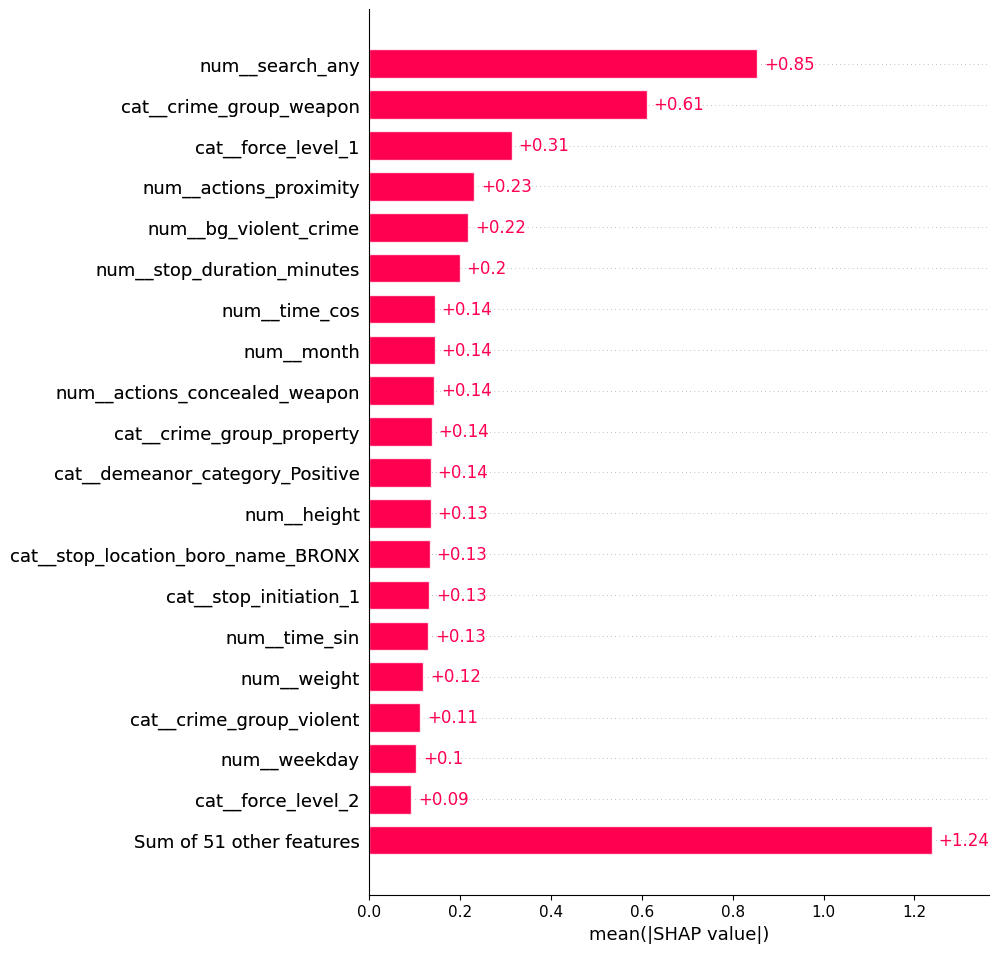

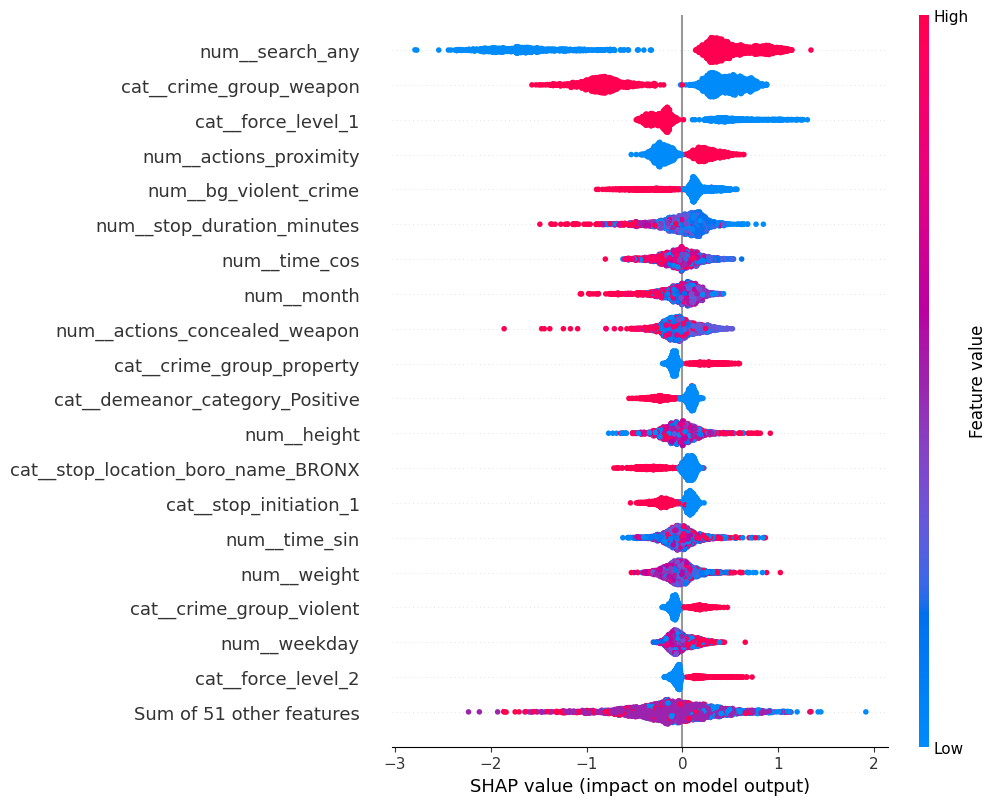

In [91]:

preprocess_acf = clf_acf.named_steps["preprocess"]
model_acf = clf_acf.named_steps["model"]

X_test_acf_trans = preprocess_acf.transform(X_test_acf)

if hasattr(X_test_acf_trans, "toarray"):
    X_test_acf_trans = X_test_acf_trans.toarray()

feature_names_acf = preprocess_acf.get_feature_names_out()

#print("Number of transformed features:", len(feature_names_acf))
#print("First 20 feature names:", feature_names_acf[:20])

explainer_acf = shap.TreeExplainer(model_acf)

shap_values_acf = explainer_acf(
    X_test_acf_trans,
    check_additivity=False
)

shap_values_acf.feature_names = feature_names_acf

shap.plots.bar(shap_values_acf, max_display=20)

shap.plots.beeswarm(shap_values_acf, max_display=20)